<a href="https://colab.research.google.com/github/personallypetra/Grand_Challenge-/blob/Cin/CinarAccenture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Factories Data Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
df_factories= pd.read_csv("F1_4_Air_Releases_Facilities.csv")

In [29]:
# ============================================================
# 1. BASIC STRUCTURE
# ============================================================
print("=" * 60)
print("1. BASIC STRUCTURE")
print("=" * 60)
print(f"Shape: {df_factories.shape[0]:,} rows x {df_factories.shape[1]} columns")
print(f"\nColumns: {list(df_factories.columns)}")
print(f"\nData types:")
print(df_factories.dtypes)

1. BASIC STRUCTURE
Shape: 59,099 rows x 16 columns

Columns: ['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorCode', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'FacilityInspireId', 'facilityName', 'city', 'Longitude', 'Latitude', 'addressConfidentialityReason', 'TargetRelease', 'Pollutant', 'Releases', 'confidentialityReason']

Data types:
PublicationDate                  object
countryName                      object
reportingYear                     int64
EPRTR_SectorCode                float64
EPRTR_SectorName                 object
EPRTRAnnexIMainActivity          object
FacilityInspireId                object
facilityName                     object
city                             object
Longitude                       float64
Latitude                        float64
addressConfidentialityReason     object
TargetRelease                    object
Pollutant                        object
Releases                        float64
confidentialityReason            objec

In [30]:
# ============================================================
# 2. FIRST & LAST ROWS
# ============================================================
print("\n" + "=" * 60)
print("2. SAMPLE ROWS")
print("=" * 60)
df_factories.head()


2. SAMPLE ROWS


,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,addressConfidentialityReason,TargetRelease,Pollutant,Releases,confidentialityReason
0,2026/02/13,Germany,2013,1.0,Energy sector,1(e),https://registry.gdi-de.org/id/de.nw.inspire.p...,RWE Power AG-Fabrik Fortuna Nord,Bergheim,6.658050,50.986950,NaN,AIR,Sulphur oxides (SOX),824000.0,NaN
1,2026/02/13,Sweden,2020,7.0,Intensive livestock production and aquaculture,7(a)(i),SE.CAED/10017896.Facility,Skåneägg Produktion AB,MÖRARP,12.849550,56.053160,NaN,AIR,Ammonia (NH3),16300.0,NaN
2,2026/02/13,Romania,2013,5.0,Waste and wastewater management,5(d),RO.CAED/104TL0001.FACILITY,SC ECOREC SA,TULCEA,28.769671,45.190459,NaN,AIR,Methane (CH4),269000.0,NaN
3,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370602036.FACILITY,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,NaN,AIR,Ammonia (NH3),31920.0,NaN
4,2026/02/13,Czechia,2007,1.0,Energy sector,1(c),CZ.MZP.U423/CZ14819275.FACILITY,energetika,Štětí,14.380370,50.462296,NaN,AIR,Sulphur oxides (SOX),507000.0,NaN


In [31]:
df_factories = df_factories[df_factories["countryName"] == "Italy"].copy()

In [32]:
df_factories = df_factories[(df_factories["reportingYear"].between(2021, 2024))
].copy()



In [33]:
# ============================================================
# 3. SUMMARY STATISTICS
# ============================================================
print("\n" + "=" * 60)
print("3. SUMMARY STATISTICS (Numeric)")
print("=" * 60)
print(df_factories.describe())

print("\n" + "=" * 60)
print("3b. SUMMARY STATISTICS (Categorical)")
print("=" * 60)
print(df_factories.describe(include="object"))


3. SUMMARY STATISTICS (Numeric)
       reportingYear  EPRTR_SectorCode    Longitude     Latitude      Releases
count    1067.000000       1066.000000  1055.000000  1055.000000  1.067000e+03
mean     2022.458294          4.803940    11.388553    43.978282  8.001544e+07
std         1.121550          2.544998     2.432031     2.285904  3.796929e+08
min      2021.000000          1.000000     7.449100    36.903056  1.020000e-04
25%      2021.000000          2.000000     9.809450    43.488567  1.233150e+04
50%      2022.000000          6.000000    10.892400    45.023600  2.473900e+04
75%      2023.000000          7.000000    12.395700    45.417211  2.535035e+05
max      2024.000000          9.000000    18.318000    46.232500  4.703125e+09

3b. SUMMARY STATISTICS (Categorical)
       PublicationDate countryName  \
count             1067        1067   
unique               1           1   
top         2026/02/13       Italy   
freq              1067        1067   

                           


4. MISSING DATA
                              count  percent
confidentialityReason          1067   100.00
addressConfidentialityReason   1055    98.88
Longitude                        12     1.12
Latitude                         12     1.12
EPRTR_SectorCode                  1     0.09
EPRTR_SectorName                  1     0.09
EPRTRAnnexIMainActivity           1     0.09
PublicationDate                   0     0.00
facilityName                      0     0.00
FacilityInspireId                 0     0.00
countryName                       0     0.00
reportingYear                     0     0.00
city                              0     0.00
TargetRelease                     0     0.00
Pollutant                         0     0.00
Releases                          0     0.00


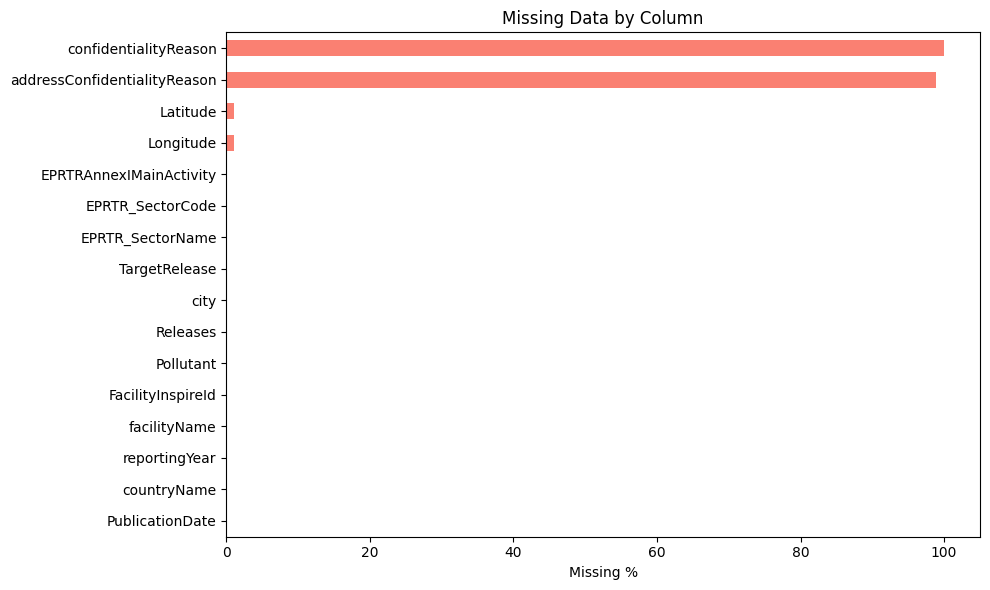

In [34]:
# ============================================================
# 4. MISSING DATA
# ============================================================
print("\n" + "=" * 60)
print("4. MISSING DATA")
print("=" * 60)
nulls = df_factories.isna().sum()
null_pct = (df_factories.isna().sum() / len(df_factories) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
null_pcts = (df_factories.isna().sum() / len(df_factories) * 100).sort_values(ascending=True)
null_pcts.plot(kind="barh", ax=ax, color="salmon")
ax.set_xlabel("Missing %")
ax.set_title("Missing Data by Column")
plt.tight_layout()
plt.show()


In [35]:
"""
Zero Value Inspection - Factories Dataset (better chart)
"""

import pandas as pd
import matplotlib.pyplot as plt

numeric_cols = df_factories.select_dtypes(include="number").columns
total_rows = len(df_factories)

print(f"Total rows: {total_rows:,}")
print(f"Numeric columns: {len(numeric_cols)}\n")

zero_summary = []
for col in numeric_cols:
    zero_count = (df_factories[col] == 0).sum()
    zero_pct = (zero_count / total_rows * 100)
    null_count = df_factories[col].isna().sum()
    zero_summary.append({
        "column": col,
        "zeros": zero_count,
        "zero_%": round(zero_pct, 2),
        "nulls": null_count,
        "total_valid": total_rows - null_count,
    })

zero_df = pd.DataFrame(zero_summary).sort_values("zero_%", ascending=False)
print(zero_df.to_string(index=False))



Total rows: 1,067
Numeric columns: 5

          column  zeros  zero_%  nulls  total_valid
   reportingYear      0     0.0      0         1067
EPRTR_SectorCode      0     0.0      1         1066
       Longitude      0     0.0     12         1055
        Latitude      0     0.0     12         1055
        Releases      0     0.0      0         1067


In [36]:

# ============================================================
# 5. UNIQUE VALUES PER COLUMN
# ============================================================
print("\n" + "=" * 60)
print("5. UNIQUE VALUES PER COLUMN")
print("=" * 60)
for col in df_factories.columns:
    print(f"  {col}: {df_factories[col].nunique()} unique")


5. UNIQUE VALUES PER COLUMN
  PublicationDate: 1 unique
  countryName: 1 unique
  reportingYear: 4 unique
  EPRTR_SectorCode: 9 unique
  EPRTR_SectorName: 9 unique
  EPRTRAnnexIMainActivity: 30 unique
  FacilityInspireId: 701 unique
  facilityName: 683 unique
  city: 542 unique
  Longitude: 683 unique
  Latitude: 680 unique
  addressConfidentialityReason: 1 unique
  TargetRelease: 1 unique
  Pollutant: 31 unique
  Releases: 1042 unique
  confidentialityReason: 0 unique


In [37]:

# ============================================================
# 6. KEY DISTRIBUTIONS
# ============================================================
print("\n" + "=" * 60)
print("6. KEY DISTRIBUTIONS")
print("=" * 60)

print("\nTop 15 Pollutants:")
print(df_factories["Pollutant"].value_counts().head(15))

print("\nReporting Year distribution:")
print(df_factories["reportingYear"].value_counts().sort_index())



6. KEY DISTRIBUTIONS

Top 15 Pollutants:
Pollutant
Ammonia (NH3)                                     499
Nitrogen oxides (NOX)                             137
Carbon dioxide (CO2)                              114
Methane (CH4)                                      55
Non-methane volatile organic compounds (NMVOC)     42
Nitrous oxide (N2O)                                25
Sulphur oxides (SOX)                               24
Carbon monoxide (CO)                               22
Zinc and compounds (as Zn)                         22
Hydro-fluorocarbons (HFCS)                         19
Benzene                                            15
Arsenic and compounds (as As)                      13
Nickel and compounds (as Ni)                       11
Mercury and compounds (as Hg)                       8
Polychlorinated biphenyls (PCBs)                    7
Name: count, dtype: int64

Reporting Year distribution:
reportingYear
2021    280
2022    276
2023    253
2024    258
Name: count, dtype: 

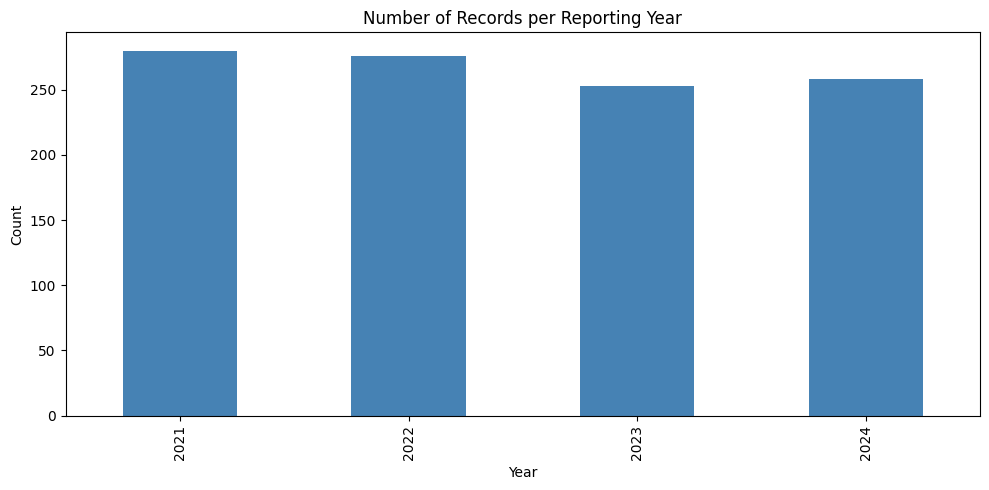

In [38]:

# ============================================================
# 7. PLOTS
# ============================================================

# 7a. Reporting Year distribution
fig, ax = plt.subplots(figsize=(10, 5))
df_factories["reportingYear"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of Records per Reporting Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()



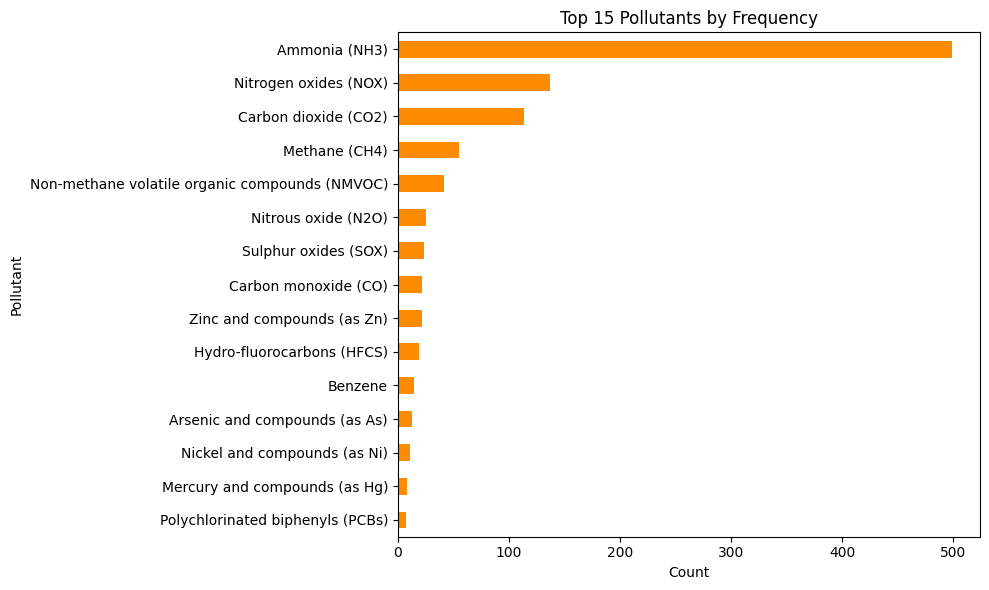

In [39]:
# 7b. Top pollutants
fig, ax = plt.subplots(figsize=(10, 6))
df_factories["Pollutant"].value_counts().head(15).plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Top 15 Pollutants by Frequency")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

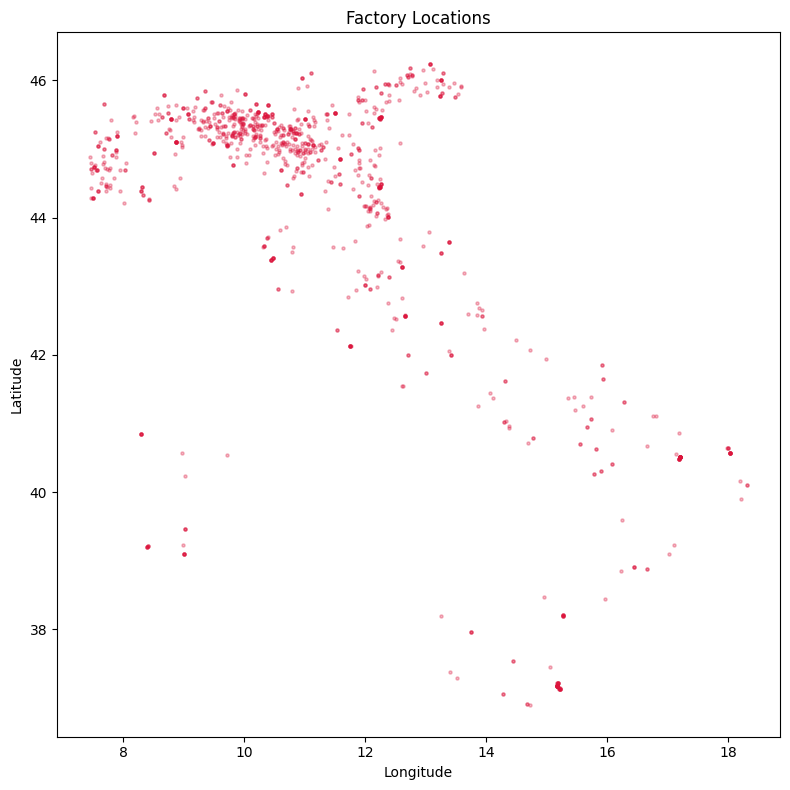


Geographic spread:
  Lat: 36.9031 to 46.2325
  Lon: 7.4491 to 18.3180


In [41]:


# 7d. Geographic distribution
if "Latitude" in df_factories.columns and "Longitude" in df_factories.columns:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(df_factories["Longitude"], df_factories["Latitude"], alpha=0.3, s=5, c="crimson")
    ax.set_title("Factory Locations")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()

    print("\nGeographic spread:")
    print(f"  Lat: {df_factories['Latitude'].min():.4f} to {df_factories['Latitude'].max():.4f}")
    print(f"  Lon: {df_factories['Longitude'].min():.4f} to {df_factories['Longitude'].max():.4f}")

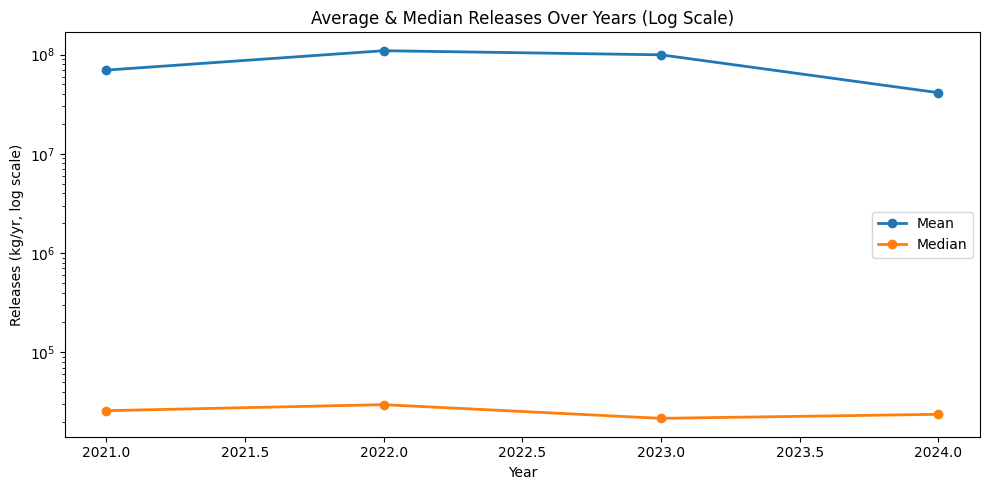

In [42]:
if "Releases" in df_factories.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    yearly = df_factories.groupby("reportingYear")["Releases"].agg(["mean", "median", "sum"])
    yearly[["mean", "median"]].plot(ax=ax, marker="o", linewidth=2)
    ax.set_yscale("log")
    ax.set_title("Average & Median Releases Over Years (Log Scale)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Releases (kg/yr, log scale)")
    ax.legend(["Mean", "Median"])
    plt.tight_layout()
    plt.show()

In [43]:
print(df_factories["Releases"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

0.25    1.233150e+04
0.50    2.473900e+04
0.75    2.535035e+05
0.90    1.129124e+08
0.95    3.817309e+08
0.99    2.015498e+09
Name: Releases, dtype: float64


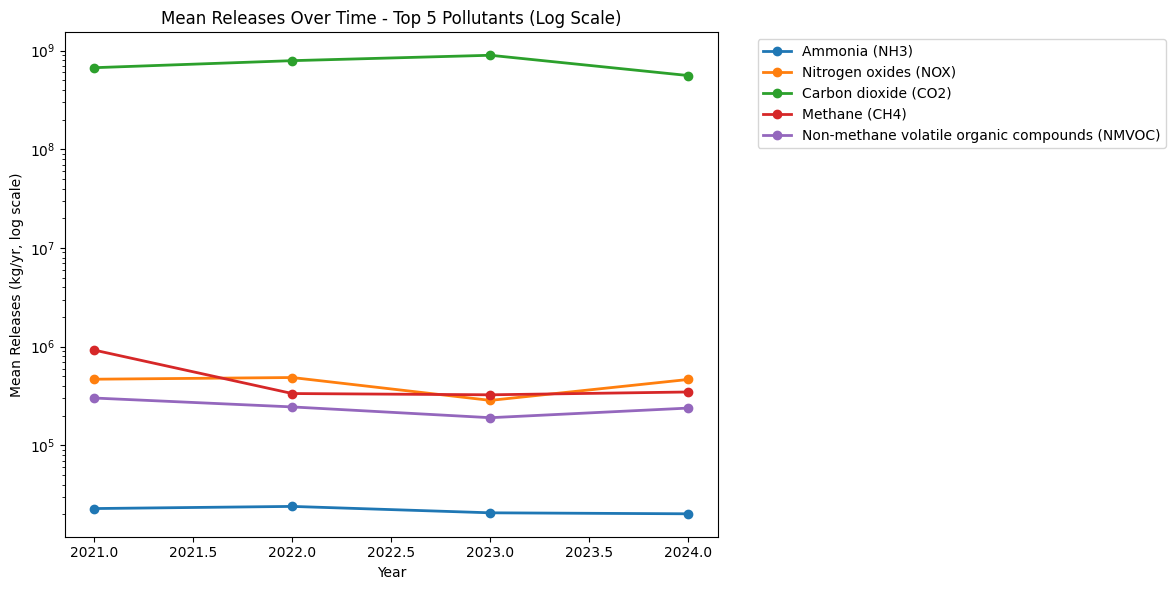

In [44]:
if "Releases" in df_factories.columns:
    top5 = df_factories["Pollutant"].value_counts().head(5).index
    fig, ax = plt.subplots(figsize=(12, 6))
    for poll in top5:
        subset = df_factories[df_factories["Pollutant"] == poll].groupby("reportingYear")["Releases"].mean()
        subset.plot(ax=ax, marker="o", label=poll, linewidth=2)
    ax.set_yscale("log")
    ax.set_title("Mean Releases Over Time - Top 5 Pollutants (Log Scale)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Releases (kg/yr, log scale)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [45]:
# ============================================================
# 8. DUPLICATE CHECK
# ============================================================
print("\n" + "=" * 60)
print("8. DUPLICATES")
print("=" * 60)
print(f"Exact duplicate rows: {df_factories.duplicated().sum()}")

# =======


8. DUPLICATES
Exact duplicate rows: 0



.


















.

#Cleaning Factories Data


In [46]:
# Drop columns that are nearly 100% null — no usable data
# confidentialityReason: 100% null
# addressConfidentialityReason: 98.97% null
df_factories = df_factories.drop(columns=["confidentialityReason", "addressConfidentialityReason"])

print(f"Remaining columns: {df_factories.shape[1]}")
print(df_factories.columns.tolist())

Remaining columns: 14
['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorCode', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'FacilityInspireId', 'facilityName', 'city', 'Longitude', 'Latitude', 'TargetRelease', 'Pollutant', 'Releases']


In [47]:
# Check if there are power/energy facilities near Rome in df_factories
# Look for energy-related activities
print(df_factories["EPRTRAnnexIMainActivity"].value_counts())

EPRTRAnnexIMainActivity
7(a)        450
1(c)        133
3(c)         73
2(b)         63
1(a)         54
3(e)         37
5(d)         32
4(a)         28
9(c)         27
4(b)         21
7(a)(ii)     20
2(e)         18
4(e)         16
5(b)         15
7(a)(i)      14
6(b)         12
8(b)         11
5(a)          9
2(a)          5
4(c)          5
3(a)          4
2(f)          4
2(d)          3
1(d)          3
5(c)          3
5(f)          2
1(b)          1
9(a)          1
9(d)          1
8(c)          1
Name: count, dtype: int64


In [48]:
print(df_factories["EPRTR_SectorName"].value_counts())

EPRTR_SectorName
Intensive livestock production and aquaculture                     484
Energy sector                                                      191
Mineral industry                                                   114
Production and processing of metals                                 93
Chemical industry                                                   70
Waste and wastewater management                                     61
Other activities                                                    29
Paper and wood production and processing                            12
Animal and vegetable products from the food and beverage sector     12
Name: count, dtype: int64


In [49]:
# Facilities within Lazio area (rough bounds)
lazio = df_factories[
    (df_factories["Latitude"].between(40.0, 44.0)) &
    (df_factories["Longitude"].between(10.0, 14.5))
]
print(f"Facilities in centra italy area: {len(lazio)}")
print(lazio[["facilityName", "EPRTR_SectorName", "Latitude", "Longitude"]].drop_duplicates())

Facilities in centra italy area: 119
                                            facilityName  \
41                           CENTRALE TORREVALDALIGA SUD   
74     ACCIAI SPECIALI TERNI S.P.A. - stabilimento di...   
626                       Società Agricola Fileni S.r.l.   
1075                             Laminazione Sottile SpA   
1418                                 ALESSANDRO STASSANO   
...                                                  ...   
53034   Complesso IPPC "Azienda Agraria Del Sero Angelo"   
53608                       TERMOVALORIZZATORE DI ACERRA   
53653                       CORNING PHARMACEUTICAL GLASS   
53712                              SOGLIANO AMBIENTE SPA   
58491                     STABILIMENTO DI SAN PELLEGRINO   

                                     EPRTR_SectorName   Latitude  Longitude  
41                                      Energy sector  42.123100  11.765400  
74                Production and processing of metals  42.566700  12.666700  
626    I

In [50]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Rome center
rome_lat, rome_lon = 41.9028, 12.4964

energy_facilities = lazio[lazio["EPRTR_SectorName"] == "Energy sector"].copy()
energy_facilities["distance_km"] = energy_facilities.apply(
    lambda r: haversine(rome_lat, rome_lon, r["Latitude"], r["Longitude"]), axis=1
)

print(energy_facilities[["facilityName", "city", "Latitude", "Longitude", "distance_km"]].drop_duplicates().sort_values("distance_km").to_string())

                                                                 facilityName                    city  Latitude  Longitude  distance_km
14419                                   CENTRALE A CICLO COMBINATO DI APRILIA                 APRILIA   41.5494    12.6308    40.848517
24093                                    Centrale compressione gas di Gallese                 GALLESE   42.3621    12.4432    51.259896
41                                                CENTRALE TORREVALDALIGA SUD           CIVITAVECCHIA   42.1231    11.7654    65.171744
2310                                             Centrale Torrevaldaliga Nord           CIVITAVECCHIA   42.1275    11.7586    65.874727
37379                           Centrale termoelettrica di Montalto di Castro      MONTALTO DI CASTRO   42.3589    11.5338    94.196925
2965          Enel Produzione S.p.A. - IMPIANTO TERMOELETTRICO DI PIETRAFITTA                 PIEGARO   42.9946    12.2003   123.809378
23341                                   Centrale

In [51]:
df_factories.to_csv("factories_last.csv", index=False)

In [53]:
df_factories.columns

Index(['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorCode',
       'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'FacilityInspireId',
       'facilityName', 'city', 'Longitude', 'Latitude', 'TargetRelease',
       'Pollutant', 'Releases'],
      dtype='object')

In [52]:
df_factories.head()

,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,TargetRelease,Pollutant,Releases
3,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370602036.FACILITY,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,AIR,Ammonia (NH3),31920.0
6,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370672013.FACILITY,ALZO S.N.C. DI BENEDETTI PIETRO E C. - SOCIETA...,VALEGGIO SUL MINCIO,10.739400,45.331700,AIR,Ammonia (NH3),27910.6
41,2026/02/13,Italy,2021,1.0,Energy sector,1(c),IT.CAED/000531001.FACILITY,CENTRALE TORREVALDALIGA SUD,CIVITAVECCHIA,11.765400,42.123100,AIR,Carbon dioxide (CO2),530453000.0
74,2026/02/13,Italy,2022,2.0,Production and processing of metals,2(b),IT.CAED/051002002.FACILITY,ACCIAI SPECIALI TERNI S.P.A. - stabilimento di...,TERNI,12.666700,42.566700,AIR,Nitrogen oxides (NOX),510200.0
92,2026/02/13,Italy,2022,5.0,Waste and wastewater management,5(d),IT.CAED/410592001.FACILITY,HERAMBIENTE S.R.L. - DISCARICA RIFIUTI NON PER...,ZOCCA,10.938600,44.340800,AIR,Methane (CH4),133874.2


In [54]:
# Drop columns not needed for analysis
# TargetRelease — not relevant
# city — all Rome/Lazio area, no variation needed
# facilityName — individual names not needed for aggregate analysis
# FacilityInspireId — identifier, not needed
# EPRTR_SectorCode — numeric code, redundant with EPRTR_SectorName
df_factories = df_factories.drop(columns=[
    "TargetRelease",
    "city",
    "facilityName",
    "FacilityInspireId",
    "EPRTR_SectorCode"
])

print(f"Remaining columns: {df_factories.columns.tolist()}")

Remaining columns: ['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'Longitude', 'Latitude', 'Pollutant', 'Releases']


In [55]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Rome center coordinates
rome_lat, rome_lon = 41.9028, 12.4964

# Calculate distance from Rome center for each facility
df_factories["distance_from_rome_km"] = df_factories.apply(
    lambda r: haversine(rome_lat, rome_lon, r["Latitude"], r["Longitude"]), axis=1
)

print(f"Distance range: {df_factories['distance_from_rome_km'].min():.1f} - {df_factories['distance_from_rome_km'].max():.1f} km")
print(f"\nDistance distribution:")
print(df_factories["distance_from_rome_km"].describe())

Distance range: 21.2 - 587.9 km

Distance distribution:
count    1055.000000
mean      391.005741
std       112.404807
min        21.188597
25%       347.936300
50%       422.495034
75%       460.332066
max       587.944281
Name: distance_from_rome_km, dtype: float64


In [57]:
df_factories.head()

,PublicationDate,countryName,reportingYear,EPRTR_SectorName,EPRTRAnnexIMainActivity,Longitude,Latitude,Pollutant,Releases,distance_from_rome_km
3,2026/02/13,Italy,2021,Intensive livestock production and aquaculture,7(a),11.106667,45.123611,Ammonia (NH3),31920.0,375.245942
6,2026/02/13,Italy,2021,Intensive livestock production and aquaculture,7(a),10.739400,45.331700,Ammonia (NH3),27910.6,406.637478
41,2026/02/13,Italy,2021,Energy sector,1(c),11.765400,42.123100,Carbon dioxide (CO2),530453000.0,65.171744
74,2026/02/13,Italy,2022,Production and processing of metals,2(b),12.666700,42.566700,Nitrogen oxides (NOX),510200.0,75.141874
92,2026/02/13,Italy,2022,Waste and wastewater management,5(d),10.938600,44.340800,Methane (CH4),133874.2,299.111506


In [59]:
df_factories = df_factories.drop(columns = "PublicationDate")

In [63]:
df_factories = df_factories.drop(columns = "countryName")

In [64]:
df_factories = df_factories.drop(columns = ["Longitude","Latitude"])

In [66]:
df_factories = df_factories.drop(columns = "EPRTRAnnexIMainActivity")

In [68]:
# Create dummy variables for EPRTR_SectorName
# drop_first=True to avoid multicollinearity
dummies = pd.get_dummies(df_factories["EPRTR_SectorName"], prefix="Sector", drop_first=True)

# Add dummies and drop original column
df_factories = pd.concat([df_factories, dummies], axis=1)
df_factories = df_factories.drop(columns=["EPRTR_SectorName"])

print(f"Shape: {df_factories.shape}")
print(f"Columns: {df_factories.columns.tolist()}")

Shape: (1067, 12)
Columns: ['reportingYear', 'Pollutant', 'Releases', 'distance_from_rome_km', 'Sector_Chemical industry', 'Sector_Energy sector', 'Sector_Intensive livestock production and aquaculture', 'Sector_Mineral industry', 'Sector_Other activities', 'Sector_Paper and wood production and processing', 'Sector_Production and processing of metals', 'Sector_Waste and wastewater management']


In [70]:
# Convert dummy columns from True/False to 0/1
dummy_cols = [c for c in df_factories.columns if c.startswith("Sector_")]
df_factories[dummy_cols] = df_factories[dummy_cols].astype(int)

print(df_factories[dummy_cols].head())

    Sector_Chemical industry  Sector_Energy sector  \
3                          0                     0   
6                          0                     0   
41                         0                     1   
74                         0                     0   
92                         0                     0   

    Sector_Intensive livestock production and aquaculture  \
3                                                   1       
6                                                   1       
41                                                  0       
74                                                  0       
92                                                  0       

    Sector_Mineral industry  Sector_Other activities  \
3                         0                        0   
6                         0                        0   
41                        0                        0   
74                        0                        0   
92                        0 

In [71]:
df_factories.head()

,reportingYear,Pollutant,Releases,distance_from_rome_km,Sector_Chemical industry,Sector_Energy sector,Sector_Intensive livestock production and aquaculture,Sector_Mineral industry,Sector_Other activities,Sector_Paper and wood production and processing,Sector_Production and processing of metals,Sector_Waste and wastewater management
3,2021,Ammonia (NH3),31920.0,375.245942,0,0,1,0,0,0,0,0
6,2021,Ammonia (NH3),27910.6,406.637478,0,0,1,0,0,0,0,0
41,2021,Carbon dioxide (CO2),530453000.0,65.171744,0,1,0,0,0,0,0,0
74,2022,Nitrogen oxides (NOX),510200.0,75.141874,0,0,0,0,0,0,1,0
92,2022,Methane (CH4),133874.2,299.111506,0,0,0,0,0,0,0,1


In [73]:
df_factories.to_csv("factories_last_1.csv", index=False)

#Air Quality Data Inspection


In [113]:
import pandas as pd

files = ["DataExtract 4.csv","DataExtract 5.csv","DataExtract 6.csv","DataExtract 7.csv"]

df_stats = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

In [114]:

# ============================================================
# 1. BASIC STRUCTURE
# ============================================================
print("=" * 60)
print("1. BASIC STRUCTURE")
print("=" * 60)
print(f"Shape: {df_stats.shape[0]:,} rows x {df_stats.shape[1]} columns")
print(f"\nData types:")
print(df_stats.dtypes)


1. BASIC STRUCTURE
Shape: 2,706 rows x 27 columns

Data types:
Country                                                            object
Air Quality Network                                                object
Air Quality Network Name                                           object
Air Quality Station EoI Code                                       object
Air Quality Station Name                                           object
Sampling Point Id                                                  object
Air Pollutant                                                      object
Air Pollutant Description                                          object
Data Aggregation Process Id                                        object
Data Aggregation Process                                           object
Year                                                                int64
Air Pollution Level                                               float64
Unit Of Air Pollution Level                      

In [115]:
df_stats

,Country,Air Quality Network,Air Quality Network Name,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Air Pollutant,Air Pollutant Description,Data Aggregation Process Id,Data Aggregation Process,...,Longitude,Latitude,Altitude,City,City Code,City Population,Source Of Data Flow,Calculation Time,Link to raw data (only E1a/validated data from AQ e-Reporting),Observation Frequency
0,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:59:18,https://eeadmz1batchservice02.blob.core.window...,hour
1,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P3Y,3 subsequent calendar years mean,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 23:01:54,https://eeadmz1batchservice02.blob.core.window...,hour
2,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y,Annual mean / 1 calendar year,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:58:16,https://eeadmz1batchservice02.blob.core.window...,hour
3,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:59:18,https://eeadmz1batchservice02.blob.core.window...,hour
4,Italy,NET.IT112A,Regione Lazio,IT1835A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-hr-per50,1 year 50 percentile,...,12.5337,41.9477,36.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 23:00:56,https://eeadmz1batchservice02.blob.core.window...,hour
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,Italy,NET.IT112A,Regione Lazio,IT1906A,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-day-min,1 year day min,...,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:59:10,https://eeadmz1batchservice02.blob.core.window...,hour
2702,Italy,NET.IT112A,Regione Lazio,IT1906A,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-dmax-per93.15,1 year 93.15 percentile daily 8h maximum,...,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 22:59:57,https://eeadmz1batchservice02.blob.core.window...,hour
2703,Italy,NET.IT112A,Regione Lazio,IT1906A,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-P1D-per99,1 year 99 percentile of daily means (P1D) or ....,...,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 23:01:47,https://eeadmz1batchservice02.blob.core.window...,hour
2704,Italy,NET.IT112A,Regione Lazio,IT1906A,ARENULA,SPO.IT1906A_8_chemi_2008-02-03_00:00:00,NO2,Nitrogen dioxide (air),P1Y-hr-max,1 year hour max,...,12.4754,41.8940,17.0,Roma ...,IT001C1 ...,2808293,E1a/validated data AQ e-Reporting,07/03/2026 23:00:20,https://eeadmz1batchservice02.blob.core.window...,hour


In [116]:
# ============================================================
# 2. SUMMARY STATISTICS
# ============================================================
print("\n" + "=" * 60)
print("2. SUMMARY STATISTICS (Numeric)")
print("=" * 60)
print(df_stats.describe())

print("\n" + "=" * 60)
print("2b. SUMMARY STATISTICS (Categorical)")
print("=" * 60)
df_stats.describe(include="object")


2. SUMMARY STATISTICS (Numeric)
              Year  Air Pollution Level  Data Coverage  Verification  \
count  2706.000000          2706.000000    2706.000000        2706.0   
mean   2022.484479           821.140721      94.674523           1.0   
std       1.118133          3809.418096       3.518019           0.0   
min    2021.000000            -1.992000      83.840000           1.0   
25%    2021.000000             0.672250      92.900000           1.0   
50%    2022.000000            25.560000      94.810000           1.0   
75%    2023.000000            85.398000      97.605000           1.0   
max    2024.000000         36627.117000     100.000000           1.0   

         Longitude     Latitude     Altitude  City Population  
count  2706.000000  2706.000000  2706.000000           2706.0  
mean     12.504233    41.906535    33.359941        2808293.0  
std       0.036858     0.031844    12.110450              0.0  
min      12.447600    41.857700    17.000000        2808293.0 

,Country,Air Quality Network,Air Quality Network Name,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Air Pollutant,Air Pollutant Description,Data Aggregation Process Id,Data Aggregation Process,Unit Of Air Pollution Level,Air Quality Station Type,Air Quality Station Area,City,City Code,Source Of Data Flow,Calculation Time,Link to raw data (only E1a/validated data from AQ e-Reporting),Observation Frequency
count,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706
unique,1,1,1,10,10,55,11,11,51,50,3,2,1,1,1,1,51,55,1
top,Italy,NET.IT112A,Regione Lazio,IT0953A,VILLA ADA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,ug/m3,Background,Urban,Roma ...,IT001C1 ...,E1a/validated data AQ e-Reporting,07/03/2026 22:59:18,https://eeadmz1batchservice02.blob.core.window...,hour
freq,2706,2706,2706,528,528,116,760,760,218,218,2206,1830,2706,2706,2706,2706,218,116,2706


In [117]:
# ============================================================
# 3. MISSING DATA
# ============================================================
print("\n" + "=" * 60)
print("3. MISSING DATA")
print("=" * 60)
nulls = df_stats.isna().sum()
null_pct = (df_stats.isna().sum() / len(df_stats) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())





3. MISSING DATA
                                                                count  percent
Country                                                             0      0.0
Air Quality Network                                                 0      0.0
Air Quality Network Name                                            0      0.0
Air Quality Station EoI Code                                        0      0.0
Air Quality Station Name                                            0      0.0
Sampling Point Id                                                   0      0.0
Air Pollutant                                                       0      0.0
Air Pollutant Description                                           0      0.0
Data Aggregation Process Id                                         0      0.0
Data Aggregation Process                                            0      0.0
Year                                                                0      0.0
Air Pollution Level                

In [118]:
# 5. KEY DISTRIBUTIONS
# ============================================================
print("\n" + "=" * 60)
print("5. KEY DISTRIBUTIONS")
print("=" * 60)

print("\nPollutants:")
print(df_stats["Air Pollutant"].value_counts())

print("\nYear distribution:")
print(df_stats["Year"].value_counts().sort_index())

print("\nStation Names:")
print(df_stats["Air Quality Station Name"].value_counts())




5. KEY DISTRIBUTIONS

Pollutants:
Air Pollutant
NO2               760
O3                696
NOX as NO2        320
NO                280
SO2               126
CO                104
C6H5-CH3           84
C6H5-C2H5          84
C6H6               84
m,p-C6H4(CH3)2     84
o-C6H4-(CH3)2      84
Name: count, dtype: int64

Year distribution:
Year
2021    687
2022    687
2023    666
2024    666
Name: count, dtype: int64

Station Names:
Air Quality Station Name
VILLA ADA            528
FERMI                328
BUFALOTTA            294
C.SO FRANCIA         276
CIPRO                252
CINECITTA            252
L.GO PERESTRELLO     252
ARENULA              252
L.GO MAGNA GRECIA    136
TIBURTINA            136
Name: count, dtype: int64


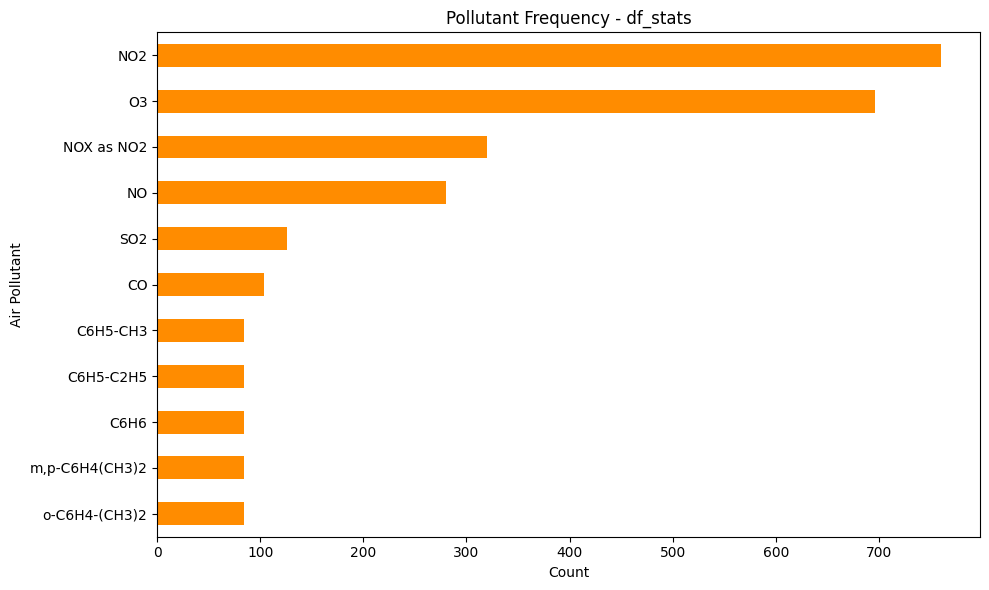

In [119]:

# 6b. Pollutant frequency
fig, ax = plt.subplots(figsize=(10, 6))
df_stats["Air Pollutant"].value_counts().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Pollutant Frequency - df_stats")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

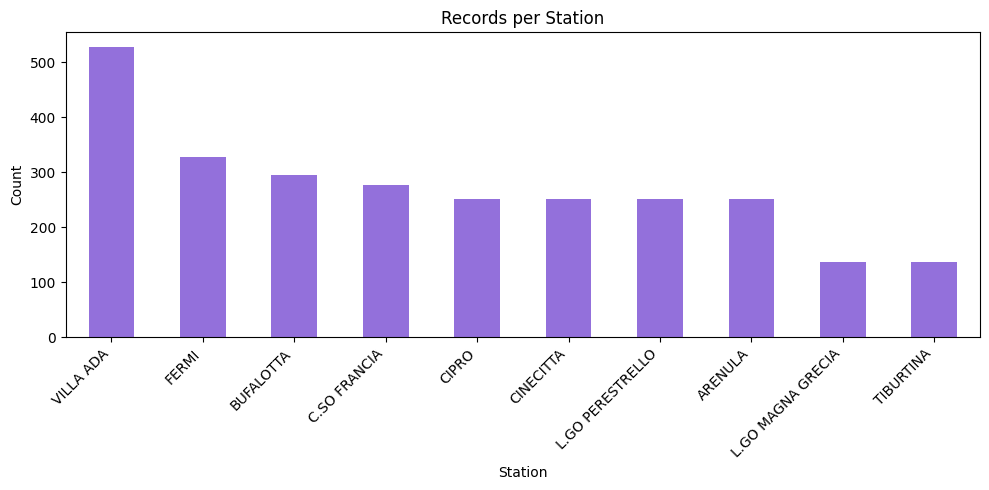

In [120]:
# 6d. Records per station
fig, ax = plt.subplots(figsize=(10, 5))
df_stats["Air Quality Station Name"].value_counts().plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("Records per Station")
ax.set_xlabel("Station")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

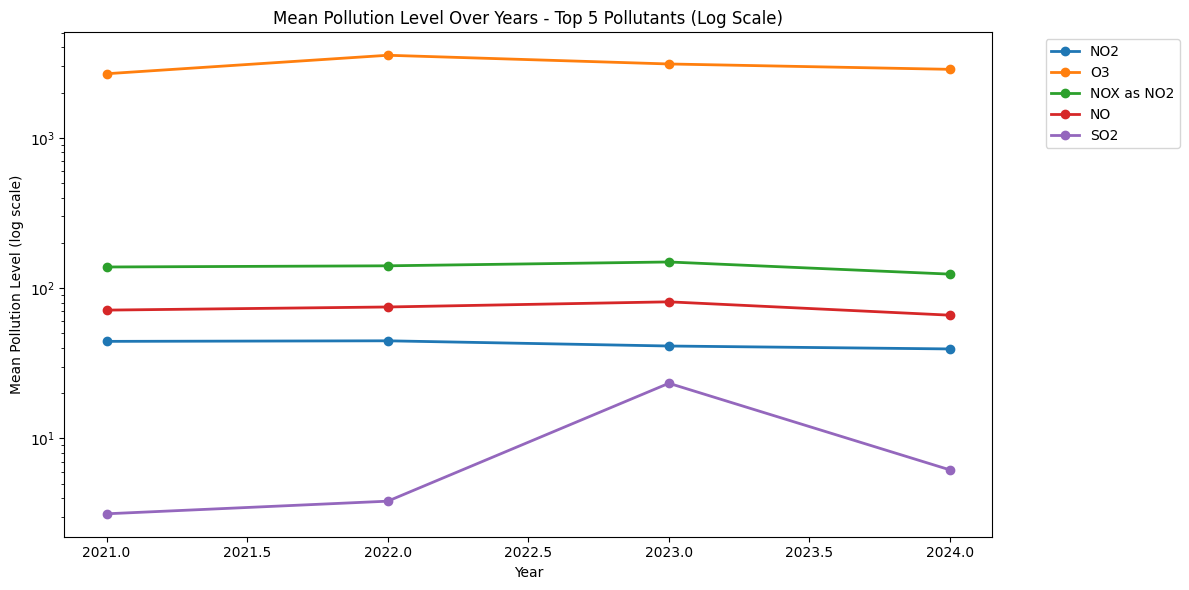

In [121]:
fig, ax = plt.subplots(figsize=(12, 6))
for poll in df_stats["Air Pollutant"].value_counts().head(5).index:
    sub = df_stats[df_stats["Air Pollutant"] == poll].groupby("Year")["Air Pollution Level"].mean()
    ax.plot(sub.index, sub.values, marker="o", linewidth=2, label=poll)
ax.set_yscale("log")
ax.set_title("Mean Pollution Level Over Years - Top 5 Pollutants (Log Scale)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Pollution Level (log scale)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [122]:
!pip install contextily

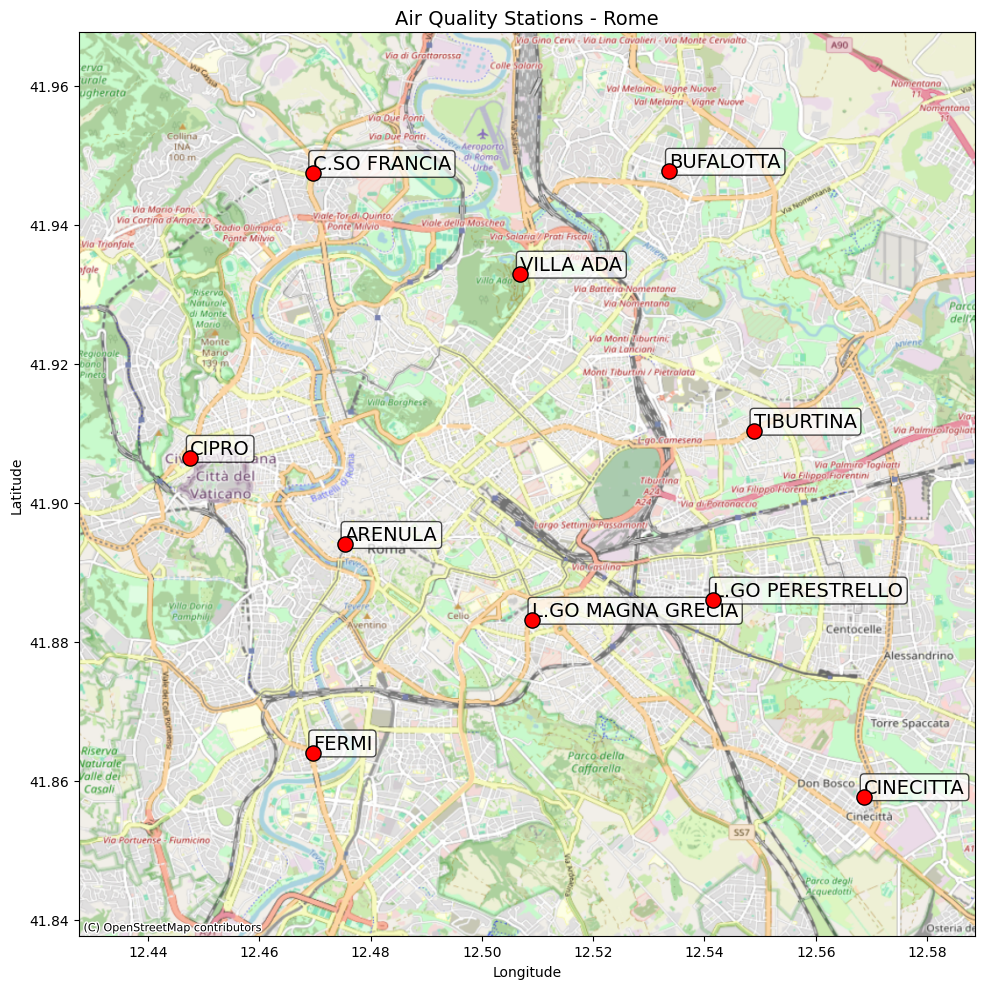

In [123]:
# Install in Colab first


import contextily as ctx
import matplotlib.pyplot as plt

stations = df_stats[["Air Quality Station Name", "Latitude", "Longitude"]].drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(stations["Longitude"], stations["Latitude"], s=120, c="red", zorder=5, edgecolors="black")

for _, row in stations.iterrows():
    ax.annotate(row["Air Quality Station Name"],
                (row["Longitude"], row["Latitude"]),
                fontsize=14, ha="left", va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

# Add some padding around the points
pad = 0.02
ax.set_xlim(stations["Longitude"].min() - pad, stations["Longitude"].max() + pad)
ax.set_ylim(stations["Latitude"].min() - pad, stations["Latitude"].max() + pad)

# Add the real map as background
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Air Quality Stations - Rome", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [124]:
# ============================================================
# 7. ZERO VALUES
# ============================================================
print("\n" + "=" * 60)
print("7. ZERO VALUES")
print("=" * 60)
numeric_cols = df_stats.select_dtypes(include="number").columns
for col in numeric_cols:
    zero_count = (df_stats[col] == 0).sum()
    if zero_count > 0:
        print(f"  {col}: {zero_count} zeros ({zero_count/len(df_stats)*100:.2f}%)")



7. ZERO VALUES
  Air Pollution Level: 424 zeros (15.67%)


In [125]:
# ============================================================
# 8. DUPLICATES
# ============================================================
print("\n" + "=" * 60)
print("8. DUPLICATES")
print("=" * 60)
print(f"Exact duplicate rows: {df_stats.duplicated().sum()}")




8. DUPLICATES
Exact duplicate rows: 0


In [126]:

# ============================================================
# 9. DATA QUALITY SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("9. DATA QUALITY SUMMARY")
print("=" * 60)
print(f"  Total rows: {len(df_stats):,}")
print(f"  Columns: {df_stats.shape[1]}")
print(f"  Columns with nulls: {(df_stats.isna().sum() > 0).sum()}")
print(f"  Exact duplicates: {df_stats.duplicated().sum()}")
print(f"  Unique stations: {df_stats['Air Quality Station Name'].nunique()}")
print(f"  Unique sampling points: {df_stats['Sampling Point Id'].nunique()}")
print(f"  Unique pollutants: {df_stats['Air Pollutant'].nunique()}")
print(f"  Year range: {df_stats['Year'].min()} - {df_stats['Year'].max()}")
print(f"  Pollution Level range: {df_stats['Air Pollution Level'].min()} - {df_stats['Air Pollution Level'].max()}")


9. DATA QUALITY SUMMARY
  Total rows: 2,706
  Columns: 27
  Columns with nulls: 0
  Exact duplicates: 0
  Unique stations: 10
  Unique sampling points: 55
  Unique pollutants: 11
  Year range: 2021 - 2024
  Pollution Level range: -1.992 - 36627.117


#air quality stats data cleaning

In [127]:
# Drop 'Country' column — all values are Italy, no information gained
df_stats = df_stats.drop(columns=["Country"])

print(f"Remaining columns: {df_stats.shape[1]}")

Remaining columns: 26


In [128]:
# Drop 'Air Quality Network Name' — all values are "Regione Lazio", no variation
df_stats = df_stats.drop(columns=["Air Quality Network Name"])

print(f"Remaining columns: {df_stats.shape[1]}")

Remaining columns: 25


In [129]:
# Drop 'Air Quality Network' — same network for all stations (NET.IT112A), no variation
df_stats = df_stats.drop(columns=["Air Quality Network"])

print(f"Remaining columns: {df_stats.shape[1]}")

Remaining columns: 24


In [130]:
# Drop 'Observation Frequency' — same value for all rows (hourly)
# Drop 'Source Of Data Flow' — same source for all rows
# Drop 'City Code' — redundant identifier, city name is sufficient
# Drop 'City Population' — constant value across all rows, no variation
# Drop 'Air Quality Station Area' — all stations are Urban, no variation
df_stats = df_stats.drop(columns=[
    "Observation Frequency",
    "Source Of Data Flow",
    "City Code",
    "City Population",
    "Air Quality Station Area",
])

print(f"Remaining columns: {df_stats.shape[1]}")
print(df_stats.columns.tolist())

Remaining columns: 19
['Air Quality Station EoI Code', 'Air Quality Station Name', 'Sampling Point Id', 'Air Pollutant', 'Air Pollutant Description', 'Data Aggregation Process Id', 'Data Aggregation Process', 'Year', 'Air Pollution Level', 'Unit Of Air Pollution Level', 'Data Coverage', 'Verification', 'Air Quality Station Type', 'Longitude', 'Latitude', 'Altitude', 'City', 'Calculation Time', 'Link to raw data (only E1a/validated data from AQ e-Reporting)']


In [131]:
df_stats = df_stats.drop(columns = "City")

In [132]:
# Drop 'Air Quality Station EoI Code' — redundant, same information as Station Name
df_stats = df_stats.drop(columns=["Air Quality Station EoI Code","Air Quality Station Type"])

print(f"Remaining columns: {df_stats.shape[1]}")
print(df_stats.columns.tolist())

Remaining columns: 16
['Air Quality Station Name', 'Sampling Point Id', 'Air Pollutant', 'Air Pollutant Description', 'Data Aggregation Process Id', 'Data Aggregation Process', 'Year', 'Air Pollution Level', 'Unit Of Air Pollution Level', 'Data Coverage', 'Verification', 'Longitude', 'Latitude', 'Altitude', 'Calculation Time', 'Link to raw data (only E1a/validated data from AQ e-Reporting)']


In [133]:
# Drop 'Data Coverage' — not needed for analysis
# Drop 'Verification' — same verification status across rows, no variation
df_stats = df_stats.drop(columns=["Data Coverage", "Verification","Calculation Time"])

print(f"Remaining columns: {df_stats.shape[1]}")
print(df_stats.columns.tolist())

Remaining columns: 13
['Air Quality Station Name', 'Sampling Point Id', 'Air Pollutant', 'Air Pollutant Description', 'Data Aggregation Process Id', 'Data Aggregation Process', 'Year', 'Air Pollution Level', 'Unit Of Air Pollution Level', 'Longitude', 'Latitude', 'Altitude', 'Link to raw data (only E1a/validated data from AQ e-Reporting)']


In [135]:
df_stats

,Air Quality Station Name,Sampling Point Id,Air Pollutant,Air Pollutant Description,Data Aggregation Process Id,Data Aggregation Process,Year,Air Pollution Level,Unit Of Air Pollution Level,Longitude,Latitude,Altitude,Link to raw data (only E1a/validated data from AQ e-Reporting)
0,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,2021,42.741,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...
1,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P3Y,3 subsequent calendar years mean,2021,43.681,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...
2,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y,Annual mean / 1 calendar year,2021,32.305,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...
3,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,2021,31.218,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...
4,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-hr-per50,1 year 50 percentile,2021,28.348,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-day-min,1 year day min,2024,2.928,ug/m3,12.4754,41.8940,17.0,https://eeadmz1batchservice02.blob.core.window...
2702,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-dmax-per93.15,1 year 93.15 percentile daily 8h maximum,2024,75.405,ug/m3,12.4754,41.8940,17.0,https://eeadmz1batchservice02.blob.core.window...
2703,ARENULA,SPO.IT1906A_7_UV-P_2009-11-29_00:00:00,O3,Ozone (air),P1Y-P1D-per99,1 year 99 percentile of daily means (P1D) or ....,2024,63.534,ug/m3,12.4754,41.8940,17.0,https://eeadmz1batchservice02.blob.core.window...
2704,ARENULA,SPO.IT1906A_8_chemi_2008-02-03_00:00:00,NO2,Nitrogen dioxide (air),P1Y-hr-max,1 year hour max,2024,116.235,ug/m3,12.4754,41.8940,17.0,https://eeadmz1batchservice02.blob.core.window...


#from parquet

In [136]:
links = df_stats[
    "Link to raw data (only E1a/validated data from AQ e-Reporting)"
].tolist()

In [137]:
df_stats = df_stats.rename(columns={"Air Pollutant": "Pollutant"})

In [138]:
"""
SCRIPT 1: Download all parquet files
=====================================
Run this first. Downloads all parquets from df_stats links to Colab local disk.
"""

import pandas as pd
import requests
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- CONFIGURATION ---
DF_STATS_PATH = "/content/df_stats.csv"  # adjust if needed
DOWNLOAD_FOLDER = "/content/parquets"
LINK_COL = "Link to raw data (only E1a/validated data from AQ e-Reporting)"

os.makedirs(DOWNLOAD_FOLDER, exist_ok=True)

# Load df_stats just to get the links
df_stats
links = df_stats[LINK_COL].dropna().unique()
parquet_links = [l for l in links if l.endswith(".parquet")]
print(f"Found {len(parquet_links)} unique parquet links\n")

# Download function
def download_one(url):
    filename = url.split("/")[-1]
    filepath = os.path.join(DOWNLOAD_FOLDER, filename)
    if os.path.exists(filepath):
        return filepath, "exists"
    try:
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        with open(filepath, "wb") as f:
            f.write(r.content)
        return filepath, "ok"
    except Exception as e:
        return None, str(e)

# Download all in parallel
start = time.time()
ok = 0
fail = 0
total = len(parquet_links)

with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {executor.submit(download_one, url): url for url in parquet_links}
    for i, future in enumerate(as_completed(futures), 1):
        filepath, status = future.result()
        if filepath:
            ok += 1
        else:
            fail += 1
            print(f"  FAILED: {futures[future].split('/')[-1]} - {status}")
        if i % 10 == 0 or i == total:
            print(f"  [{i}/{total}] Downloaded: {ok} | Failed: {fail}")

elapsed = time.time() - start
total_mb = sum(
    os.path.getsize(os.path.join(DOWNLOAD_FOLDER, f))
    for f in os.listdir(DOWNLOAD_FOLDER) if f.endswith(".parquet")
) / (1024 * 1024)

print(f"\nDone in {elapsed:.1f}s")
print(f"Files in {DOWNLOAD_FOLDER}: {ok}")
print(f"Total size: {total_mb:.1f} MB")

Found 55 unique parquet links

  [10/55] Downloaded: 10 | Failed: 0
  [20/55] Downloaded: 20 | Failed: 0
  [30/55] Downloaded: 30 | Failed: 0
  [40/55] Downloaded: 40 | Failed: 0
  [50/55] Downloaded: 50 | Failed: 0
  [55/55] Downloaded: 55 | Failed: 0

Done in 4.0s
Files in /content/parquets: 55
Total size: 67.2 MB


In [139]:
"""
SCRIPT 2: Combine all parquets into one file
=============================================
Reads all parquet files from /content/parquets/,
combines them into one dataframe, saves as CSV.
"""

import pandas as pd
import os
import gc
import glob
import time

# --- CONFIGURATION ---
PARQUET_FOLDER = "/content/parquets"
OUTPUT_PATH = "/content/all_parquets_combined.csv"

# Get all parquet files
parquet_files = sorted(glob.glob(os.path.join(PARQUET_FOLDER, "*.parquet")))
print(f"Found {len(parquet_files)} parquet files\n")

# Read all
start = time.time()
all_dfs = []

for i, filepath in enumerate(parquet_files, 1):
    df = pd.read_parquet(filepath)
    all_dfs.append(df)

    if i == 1:
        print(f"Columns: {list(df.columns)}")
        print(f"First file rows: {len(df):,}\n")

    if i % 10 == 0 or i == len(parquet_files):
        print(f"  [{i}/{len(parquet_files)}] read")

# Combine
print("\nCombining...")
df_combined = pd.concat(all_dfs, ignore_index=True)
del all_dfs
gc.collect()

print(f"Total rows: {df_combined.shape[0]:,}")
print(f"Columns: {df_combined.shape[1]}")
print(f"Memory: {df_combined.memory_usage(deep=True).sum() / (1024*1024):.0f} MB")

# Save
print(f"\nSaving to {OUTPUT_PATH}...")
df_combined.to_csv(OUTPUT_PATH, index=False)
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)

elapsed = time.time() - start
print(f"Saved: {size_mb:.1f} MB | Done in {elapsed:.1f}s")

Found 55 parquet files

Columns: ['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog']
First file rows: 87,672

  [10/55] read
  [20/55] read
  [30/55] read
  [40/55] read
  [50/55] read
  [55/55] read

Combining...
Total rows: 4,659,792
Columns: 12
Memory: 2029 MB

Saving to /content/all_parquets_combined.csv...
Saved: 805.9 MB | Done in 79.1s


In [140]:
"""
SCRIPT 3: Extract Year from Start column
=========================================
Reads the combined parquets CSV, adds a Year column
from the Start column, saves back.
"""

import pandas as pd
import time

# --- CONFIGURATION ---
INPUT_PATH = "/content/all_parquets_combined.csv"
OUTPUT_PATH = "/content/all_parquets_combined_year.csv"  # overwrite same file

print("Loading combined parquets...")
start = time.time()

df = pd.read_csv(INPUT_PATH)
print(f"Rows: {df.shape[0]:,}")

# Convert Start to datetime and extract Year
df["Start"] = pd.to_datetime(df["Start"])
df["Year"] = df["Start"].dt.year.astype(int)

print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")
print(f"Sample:\n{df[['Start', 'Year']].head()}\n")

# Save
print("Saving...")
df.to_csv(OUTPUT_PATH, index=False)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f}s")

Loading combined parquets...
Rows: 4,659,792
Year range: 2013 - 2024
Sample:
                Start  Year
0 2015-01-01 00:00:00  2015
1 2015-01-01 01:00:00  2015
2 2015-01-01 02:00:00  2015
3 2015-01-01 03:00:00  2015
4 2015-01-01 04:00:00  2015

Saving...
Done in 73.1s


In [ ]:
prefinal_df = pd.read_csv("all_parquets_combined_year.csv")

In [ ]:
# ============================================================
# 1. BASIC STRUCTURE
# ============================================================
print("=" * 60)
print("1. BASIC STRUCTURE")
print("=" * 60)
print(f"Shape: {prefinal_df.shape[0]:,} rows x {prefinal_df.shape[1]} columns")
print(f"\nColumns: {prefinal_df.columns.tolist()}")
print(f"\nData types:")
print(prefinal_df.dtypes)
print(f"\nFirst 5 rows:")
prefinal_df.head()

1. BASIC STRUCTURE
Shape: 4,659,792 rows x 13 columns

Columns: ['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog', 'Year']

Data types:
Samplingpoint        object
Pollutant             int64
Start                object
End                  object
Value               float64
Unit                 object
AggType              object
Validity              int64
Verification          int64
ResultTime           object
DataCapture         float64
FkObservationLog     object
Year                  int64
dtype: object

First 5 rows:


,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,FkObservationLog,Year
0,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 00:00:00,2015-01-01 01:00:00,0.4,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
1,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 01:00:00,2015-01-01 02:00:00,-999.0,ug.m-3,hour,-1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
2,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 02:00:00,2015-01-01 03:00:00,1.4,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
3,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 03:00:00,2015-01-01 04:00:00,1.6,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
4,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 04:00:00,2015-01-01 05:00:00,1.3,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015


In [ ]:
# ============================================================
# 2. SUMMARY STATISTICS
# ============================================================
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("\n" + "=" * 60)
print("2. SUMMARY STATISTICS (Numeric)")
print("=" * 60)
print(prefinal_df.describe())

print("\n" + "=" * 60)
print("2b. SUMMARY STATISTICS (Categorical)")
print("=" * 60)
print(prefinal_df.describe(include="object"))


2. SUMMARY STATISTICS (Numeric)
       Pollutant      Value   Validity  Verification  DataCapture       Year
count 4659792.00 4659792.00 4659792.00    4659792.00         0.00 4659792.00
mean       75.02    -444.03       0.96          1.00          NaN    2019.14
std       152.58    2100.45       0.56          0.00          NaN       3.47
min         1.00   -9999.00      -1.00          1.00          NaN    2013.00
25%         8.00       0.91       1.00          1.00          NaN    2017.00
50%         9.00      11.00       1.00          1.00          NaN    2020.00
75%        38.00      43.05       1.00          1.00          NaN    2022.00
max       482.00    1701.00       2.00          1.00          NaN    2024.00

2b. SUMMARY STATISTICS (Categorical)
                                     Samplingpoint                Start  \
count                                      4659792              4659792   
unique                                          55               105192   
top     IT/

In [ ]:
prefinal_df = prefinal_df[prefinal_df["Year"].between(2021, 2024)].copy()


In [ ]:
prefinal_df.shape

(4659792, 13)

In [ ]:

# ============================================================
# 3. MISSING DATA
# ============================================================
print("\n" + "=" * 60)
print("3. MISSING DATA")
print("=" * 60)
nulls = prefinal_df.isna().sum()
null_pct = (prefinal_df.isna().sum() / len(prefinal_df) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())





3. MISSING DATA
                    count  percent
DataCapture       1910976   100.00
Pollutant               0     0.00
Start                   0     0.00
End                     0     0.00
Samplingpoint           0     0.00
Value                   0     0.00
Unit                    0     0.00
Validity                0     0.00
AggType                 0     0.00
Verification            0     0.00
ResultTime              0     0.00
FkObservationLog        0     0.00
Year                    0     0.00


In [ ]:

# ============================================================
# 4. UNIQUE VALUES
# ============================================================
print("\n" + "=" * 60)
print("4. UNIQUE VALUES PER COLUMN")
print("=" * 60)
for col in prefinal_df.columns:
    print(f"  {col}: {prefinal_df[col].nunique()} unique")


4. UNIQUE VALUES PER COLUMN
  Samplingpoint: 55 unique
  Pollutant: 11 unique
  Start: 35064 unique
  End: 35064 unique
  Value: 983463 unique
  Unit: 2 unique
  AggType: 1 unique
  Validity: 3 unique
  Verification: 1 unique
  ResultTime: 4 unique
  DataCapture: 0 unique
  FkObservationLog: 273 unique
  Year: 4 unique


In [ ]:
# ============================================================
# 5. KEY DISTRIBUTIONS
# ============================================================
print("\n" + "=" * 60)
print("5. KEY DISTRIBUTIONS")
print("=" * 60)

print("\nPollutants:")
print(prefinal_df["Pollutant"].value_counts())

print("\nUnit:")
print(prefinal_df["Unit"].value_counts())



5. KEY DISTRIBUTIONS

Pollutants:
Pollutant
38     350640
9      350640
8      350640
7      210384
20     105192
21     105192
431    105192
482    105192
464    105192
10      70128
1       52584
Name: count, dtype: int64

Unit:
Unit
ug.m-3    1840848
mg.m-3      70128
Name: count, dtype: int64


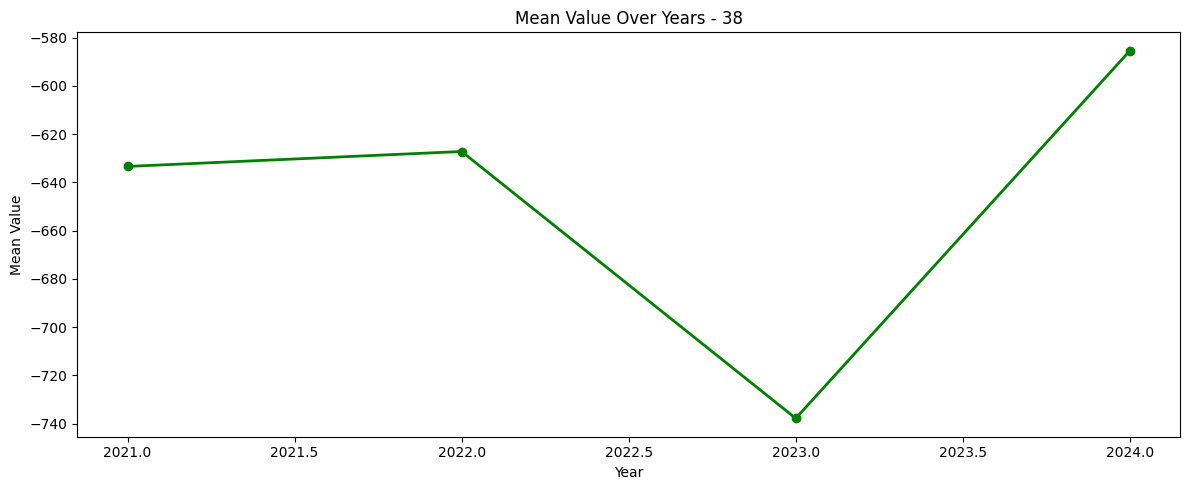

In [ ]:
# 7d. Mean value over time - dominant pollutant alone
top_poll = prefinal_df["Pollutant"].value_counts().head(5).index
dominant = top_poll[0]

fig, ax = plt.subplots(figsize=(12, 5))
sub = prefinal_df[prefinal_df["Pollutant"] == dominant].groupby("Year")["Value"].mean()
ax.plot(sub.index, sub.values, marker="o", linewidth=2, color="green")
ax.set_title(f"Mean Value Over Years - {dominant}")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Value")
plt.tight_layout()
plt.show()

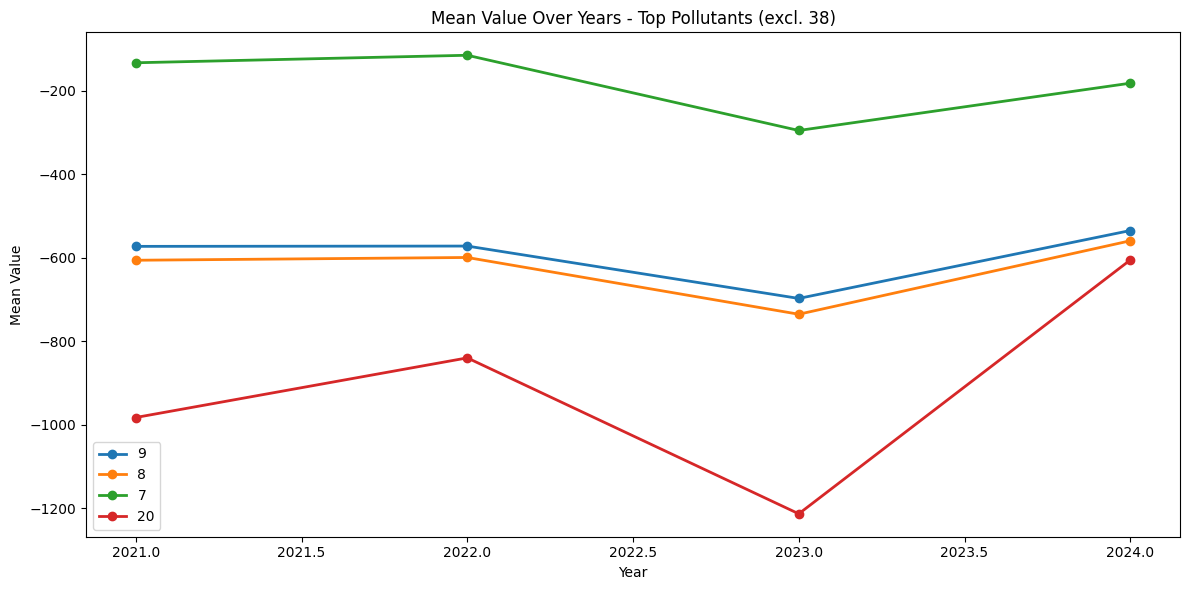

In [ ]:

# 7e. Mean value over time - others
others = [p for p in top_poll if p != dominant]
if others:
    fig, ax = plt.subplots(figsize=(12, 6))
    for poll in others:
        sub = prefinal_df[prefinal_df["Pollutant"] == poll].groupby("Year")["Value"].mean()
        ax.plot(sub.index, sub.values, marker="o", linewidth=2, label=poll)
    ax.set_title(f"Mean Value Over Years - Top Pollutants (excl. {dominant})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Value")
    ax.legend()
    plt.tight_layout()
    plt.show()


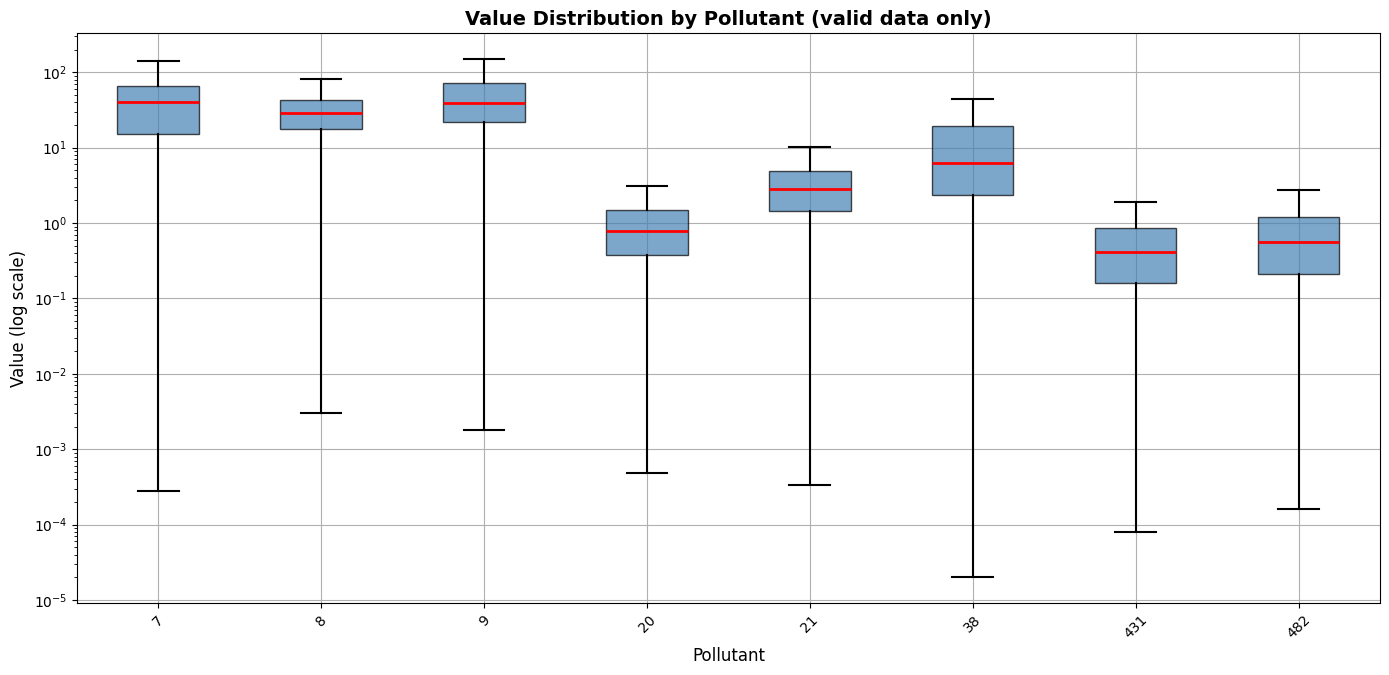

In [ ]:
top8 = prefinal_df["Pollutant"].value_counts().head(8).index
subset = prefinal_df[(prefinal_df["Pollutant"].isin(top8)) &
                      (prefinal_df["Value"] > 0)]

fig, ax = plt.subplots(figsize=(14, 7))
subset.boxplot(column="Value", by="Pollutant", ax=ax, rot=45,
               showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="red", linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5))
ax.set_yscale("log")
ax.set_title("Value Distribution by Pollutant (valid data only)", fontsize=14, fontweight="bold")
ax.set_xlabel("Pollutant", fontsize=12)
ax.set_ylabel("Value (log scale)", fontsize=12)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 8. ZERO & NEGATIVE VALUES
# ============================================================
print("\n" + "=" * 60)
print("8. ZERO & NEGATIVE VALUES")
print("=" * 60)
zero_count = (prefinal_df["Value"] == 0).sum()
neg_count = (prefinal_df["Value"] < 0).sum()
null_count = prefinal_df["Value"].isna().sum()
print(f"  Zeros: {zero_count:,} ({zero_count/len(prefinal_df)*100:.2f}%)")
print(f"  Negatives: {neg_count:,} ({neg_count/len(prefinal_df)*100:.2f}%)")
print(f"  Nulls: {null_count:,} ({null_count/len(prefinal_df)*100:.2f}%)")

if neg_count > 0:
    print(f"\n  Min negative value: {prefinal_df['Value'].min()}")
    print(f"  Negatives by pollutant:")
    negs = prefinal_df[prefinal_df["Value"] < 0]
    print(negs["Pollutant"].value_counts())



8. ZERO & NEGATIVE VALUES
  Zeros: 65,296 (3.42%)
  Negatives: 133,558 (6.99%)
  Nulls: 0 (0.00%)

  Min negative value: -9999.0
  Negatives by pollutant:
Pollutant
38     25352
8      23037
9      22784
20      9584
482     9358
21      9286
464     9246
431     9243
1       8253
7       5251
10      2164
Name: count, dtype: int64


In [ ]:
# Zero and negative breakdown by pollutant
print("=== ZEROS BY POLLUTANT ===")
for poll in prefinal_df["Pollutant"].unique():
    sub = prefinal_df[prefinal_df["Pollutant"] == poll]
    zeros = (sub["Value"] == 0).sum()
    negs = (sub["Value"] < 0).sum()
    nulls = sub["Value"].isna().sum()
    total = len(sub)
    print(f"  Pollutant {poll}: zeros={zeros:,} ({zeros/total*100:.1f}%) | "
          f"negatives={negs:,} ({negs/total*100:.1f}%) | "
          f"nulls={nulls:,} ({nulls/total*100:.1f}%) | total={total:,}")

# Check: are negatives very small (sensor noise) or large?
negs = prefinal_df[prefinal_df["Value"] < 0]
if len(negs) > 0:
    print(f"\n=== NEGATIVE VALUES ===")
    print(f"Count: {len(negs):,}")
    print(f"Range: {negs['Value'].min():.4f} to {negs['Value'].max():.4f}")
    print(f"\nDistribution:")
    print(negs["Value"].describe())

=== ZEROS BY POLLUTANT ===
  Pollutant 20: zeros=6,370 (6.1%) | negatives=9,584 (9.1%) | nulls=0 (0.0%) | total=105,192
  Pollutant 21: zeros=1,033 (1.0%) | negatives=9,286 (8.8%) | nulls=0 (0.0%) | total=105,192
  Pollutant 38: zeros=2,848 (0.8%) | negatives=25,352 (7.2%) | nulls=0 (0.0%) | total=350,640
  Pollutant 431: zeros=27,717 (26.3%) | negatives=9,243 (8.8%) | nulls=0 (0.0%) | total=105,192
  Pollutant 464: zeros=6,381 (6.1%) | negatives=9,246 (8.8%) | nulls=0 (0.0%) | total=105,192
  Pollutant 482: zeros=20,419 (19.4%) | negatives=9,358 (8.9%) | nulls=0 (0.0%) | total=105,192
  Pollutant 8: zeros=39 (0.0%) | negatives=23,037 (6.6%) | nulls=0 (0.0%) | total=350,640
  Pollutant 9: zeros=22 (0.0%) | negatives=22,784 (6.5%) | nulls=0 (0.0%) | total=350,640
  Pollutant 10: zeros=0 (0.0%) | negatives=2,164 (3.1%) | nulls=0 (0.0%) | total=70,128
  Pollutant 1: zeros=22 (0.0%) | negatives=8,253 (15.7%) | nulls=0 (0.0%) | total=52,584
  Pollutant 7: zeros=445 (0.2%) | negatives=5,251 

In [ ]:
# Are zeros happening at specific hours? (sensor downtime = midnight/maintenance?)
prefinal_df["Hour"] = pd.to_datetime(prefinal_df["Start"]).dt.hour
zeros = prefinal_df[prefinal_df["Value"] == 0]

print("Zeros by hour:")
print(zeros["Hour"].value_counts().sort_index())

print("\nZeros by Validity flag:")
print(zeros["Validity"].value_counts())

print("\nNon-zero data by Validity flag:")
valid_data = prefinal_df[(prefinal_df["Value"] > 0)]
print(valid_data["Validity"].value_counts())



Zeros by hour:
Hour
0     2592
1     2733
2     2899
3     3221
4     3706
5     3535
6     2754
7     2127
8     1782
9     1869
10    2076
11    2440
12    2801
13    3183
14    3425
15    3454
16    3201
17    2943
18    2597
19    2310
20    2306
21    2375
22    2418
23    2549
Name: count, dtype: int64

Zeros by Validity flag:
Validity
2    65296
Name: count, dtype: int64

Non-zero data by Validity flag:
Validity
1    1595145
2     116977
Name: count, dtype: int64


In [ ]:
# ============================================================
# 9. DUPLICATES
# ============================================================
print("\n" + "=" * 60)
print("9. DUPLICATES")
print("=" * 60)
print(f"Exact duplicate rows: {prefinal_df.duplicated().sum()}")
print(f"Duplicates by Samplingpoint + Start: {prefinal_df.duplicated(subset=['Samplingpoint', 'Start']).sum()}")
print(f"Duplicates by Samplingpoint + Start + Pollutant: {prefinal_df.duplicated(subset=['Samplingpoint', 'Start', 'Pollutant']).sum()}")


9. DUPLICATES
Exact duplicate rows: 0
Duplicates by Samplingpoint + Start: 0
Duplicates by Samplingpoint + Start + Pollutant: 0


In [ ]:
# ============================================================
# 10. DATA QUALITY SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("10. DATA QUALITY SUMMARY")
print("=" * 60)
print(f"  Total rows: {len(prefinal_df):,}")
print(f"  Columns: {prefinal_df.shape[1]}")
print(f"  Columns with nulls: {(prefinal_df.isna().sum() > 0).sum()}")
print(f"  Exact duplicates: {prefinal_df.duplicated().sum()}")
print(f"  Unique sampling points: {prefinal_df['Samplingpoint'].nunique()}")
print(f"  Unique pollutants: {prefinal_df['Pollutant'].nunique()}")
print(f"  Year range: {prefinal_df['Year'].min()} - {prefinal_df['Year'].max()}")
print(f"  Value range: {prefinal_df['Value'].min()} to {prefinal_df['Value'].max()}")
print(f"  Zero values: {(prefinal_df['Value'] == 0).sum():,}")
print(f"  Negative values: {(prefinal_df['Value'] < 0).sum():,}")


10. DATA QUALITY SUMMARY
  Total rows: 1,910,976
  Columns: 14
  Columns with nulls: 1
  Exact duplicates: 0
  Unique sampling points: 55
  Unique pollutants: 11
  Year range: 2021 - 2024
  Value range: -9999.0 to 1135.98413
  Zero values: 65,296
  Negative values: 133,558


In [ ]:
"""
Map all air quality stations from df_stats with their location info
Shows: station name, coordinates, altitude, and what pollutants they measure
"""

import pandas as pd

DF_STATS_PATH = "/content/df_stats.csv"

df = df_stats

# Group by station: get location + list of pollutants
stations = df.groupby("Air Quality Station Name").agg({
    "Latitude": "first",
    "Longitude": "first",
    "Altitude": "first",
    "Air Quality Station Type": "first",
    "Air Quality Station Area": "first",
    "City": "first",
    "Sampling Point Id": "nunique",
    "Pollutant": lambda x: list(x.unique()),
    "Year": lambda x: f"{x.min()}-{x.max()}",
}).reset_index()

stations.columns = [
    "Station", "Lat", "Lon", "Altitude", "Type", "Area",
    "City", "Num_SamplingPoints", "Pollutants", "Year_Range"
]

stations = stations.sort_values("Station").reset_index(drop=True)

print(f"Total unique stations: {len(stations)}\n")

for _, row in stations.iterrows():
    print(f"Station: {row['Station']}")
    print(f"  Coordinates: {row['Lat']}, {row['Lon']}")
    print(f"  Altitude: {row['Altitude']}m")
    print(f"  Type: {row['Type']} | Area: {row['Area']}")
    print(f"  City: {row['City'].strip()}")
    print(f"  Sampling Points: {row['Num_SamplingPoints']}")
    print(f"  Pollutants: {row['Pollutants']}")
    print(f"  Years: {row['Year_Range']}")
    print()

# Also show the geographic spread
print("=" * 50)
print("GEOGRAPHIC SPREAD:")
print(f"  Lat range: {stations['Lat'].min()} - {stations['Lat'].max()}")
print(f"  Lon range: {stations['Lon'].min()} - {stations['Lon'].max()}")

# Distance between furthest stations (rough km)
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

max_dist = 0
for i, r1 in stations.iterrows():
    for j, r2 in stations.iterrows():
        d = haversine(r1['Lat'], r1['Lon'], r2['Lat'], r2['Lon'])
        if d > max_dist:
            max_dist = d
            pair = (r1['Station'], r2['Station'])

print(f"  Max distance between stations: {max_dist:.1f} km ({pair[0]} <-> {pair[1]})")
print(f"  Altitude range: {stations['Altitude'].min()}m - {stations['Altitude'].max()}m")

#parquet table cleaning

In [ ]:
# Drop 'AggType' — not useful for analysis
# Drop 'ResultTime' — only 4 unique values, not informative
# Drop 'DataCapture' — 100% NaN, no data
# Drop 'FkObservationLog' — not useful for analysis
prefinal_df = prefinal_df.drop(columns=["AggType", "ResultTime", "DataCapture", "FkObservationLog"])

print(f"Remaining columns: {prefinal_df.shape[1]}")
print(prefinal_df.columns.tolist())

Remaining columns: 9
['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit', 'Validity', 'Verification', 'Year']


In [ ]:
# Remove 'IT/' prefix from Samplingpoint in prefinal_df to match df_stats format
# df_stats uses: SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00
# prefinal_df uses: IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00
prefinal_df["Samplingpoint"] = prefinal_df["Samplingpoint"].str.replace("IT/", "", n=1)

# Verify
print("Prefinal sample:", prefinal_df["Samplingpoint"].iloc[0])

Prefinal sample: SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00


In [ ]:
# Replace ALL Validity=2 values with NaN — Validity 2 means "not valid/unreliable"
# This covers zeros, negatives, and any other values flagged as invalid
v2_count = (prefinal_df["Validity"] == 2).sum()

prefinal_df.loc[prefinal_df["Validity"] == 2, "Value"] = np.nan

print(f"Validity=2 values replaced: {v2_count:,}")
print(f"Total NaN in Value now: {prefinal_df['Value'].isna().sum():,}")

Validity=2 values replaced: 188,097
Total NaN in Value now: 188,097


In [ ]:
# Replace any remaining negative values with NaN — sensor noise/artifacts
remaining_neg = (prefinal_df["Value"] < 0).sum()

prefinal_df.loc[prefinal_df["Value"] < 0, "Value"] = np.nan

print(f"Remaining negatives replaced: {remaining_neg:,}")
print(f"Total NaN in Value now: {prefinal_df['Value'].isna().sum():,}")

Remaining negatives replaced: 127,734
Total NaN in Value now: 315,831


In [ ]:
df_stats.head()

,Air Quality Network,Air Quality Station Name,Sampling Point Id,Pollutant,Air Pollutant Description,Data Aggregation Process Id,Data Aggregation Process,Year,Air Pollution Level,Unit Of Air Pollution Level,Longitude,Latitude,Altitude,Link to raw data (only E1a/validated data from AQ e-Reporting)
0,NET.IT112A,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,2021,42.741,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...
1,NET.IT112A,BUFALOTTA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,O3,Ozone (air),P3Y,3 subsequent calendar years mean,2021,43.681,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...
2,NET.IT112A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y,Annual mean / 1 calendar year,2021,32.305,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...
3,NET.IT112A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,2021,31.218,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...
4,NET.IT112A,BUFALOTTA,SPO.IT1835A_8_chemi_2019-03-18_00:00:00,NO2,Nitrogen dioxide (air),P1Y-hr-per50,1 year 50 percentile,2021,28.348,ug/m3,12.5337,41.9477,36.0,https://eeadmz1batchservice02.blob.core.window...


In [ ]:
# Drop 'Unit Of Air Pollution Level' — unit info already in prefinal_df's 'Unit' column
# Drop 'Air Pollution Level' — aggregated stat, prefinal_df has the actual hourly values
df_stats = df_stats.drop(columns=["Unit Of Air Pollution Level", "Air Pollution Level"])

print(f"Remaining columns: {df_stats.shape[1]}")
print(df_stats.columns.tolist())

Remaining columns: 12
['Air Quality Network', 'Air Quality Station Name', 'Sampling Point Id', 'Pollutant', 'Air Pollutant Description', 'Data Aggregation Process Id', 'Data Aggregation Process', 'Year', 'Longitude', 'Latitude', 'Altitude', 'Link to raw data (only E1a/validated data from AQ e-Reporting)']


In [ ]:
prefinal_df.head()

,Samplingpoint,Pollutant,Start,End,Value,Unit,Validity,Verification,Year
52608,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 00:00:00,2021-01-01 01:00:00,2.34430,ug.m-3,1,1,2021
52609,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 01:00:00,2021-01-01 02:00:00,NaN,ug.m-3,-1,1,2021
52610,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 02:00:00,2021-01-01 03:00:00,2.32277,ug.m-3,1,1,2021
52611,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 03:00:00,2021-01-01 04:00:00,2.04669,ug.m-3,1,1,2021
52612,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 04:00:00,2021-01-01 05:00:00,1.75685,ug.m-3,1,1,2021


In [ ]:
# Check df_stats: same Samplingpoint + Year, different pollutants
stats_grouped = df_stats.groupby(["Sampling Point Id", "Year"])["Pollutant"].nunique().reset_index()
stats_multi = stats_grouped[stats_grouped["Pollutant"] > 1]
print("df_stats:")
print(f"  Total Samplingpoint+Year groups: {len(stats_grouped)}")
print(f"  Groups with multiple pollutants: {len(stats_multi)}")

# Check prefinal_df: same Samplingpoint + Year, different pollutants
pf_grouped = prefinal_df.groupby(["Samplingpoint", "Year"])["Pollutant"].nunique().reset_index()
pf_multi = pf_grouped[pf_grouped["Pollutant"] > 1]
print("\nprefinal_df:")
print(f"  Total Samplingpoint+Year groups: {len(pf_grouped)}")
print(f"  Groups with multiple pollutants: {len(pf_multi)}")

# Show examples if any
if len(pf_multi) > 0:
    print("\nPrefinal examples:")
    for _, row in pf_multi.head(3).iterrows():
        sp = row["Samplingpoint"]
        yr = row["Year"]
        sub = prefinal_df[(prefinal_df["Samplingpoint"] == sp) & (prefinal_df["Year"] == yr)]
        print(f"  {sp} | Year: {yr} | Pollutant: {sub['Pollutant'].unique()}")

df_stats:
  Total Samplingpoint+Year groups: 218
  Groups with multiple pollutants: 0

prefinal_df:
  Total Samplingpoint+Year groups: 218
  Groups with multiple pollutants: 0


In [ ]:
# Drop Pollutant_code from prefinal_df — each Samplingpoint+Year already maps to one pollutant
# Pollutant name will come from df_stats after merging on Samplingpoint + Year
prefinal_df = prefinal_df.drop(columns=["Pollutant"])

print(f"Remaining columns: {prefinal_df.columns.tolist()}")

Remaining columns: ['Samplingpoint', 'Start', 'End', 'Value', 'Unit', 'Validity', 'Verification', 'Year']


In [ ]:
# Merge df_stats columns into prefinal_df
# Each Samplingpoint+Year in prefinal gets the matching df_stats row pasted to the right
# Rename df_stats column to match prefinal naming
df_stats = df_stats.rename(columns={"Sampling Point Id": "Samplingpoint"})

print(f"prefinal_df: {len(prefinal_df):,} rows, {prefinal_df.shape[1]} columns")
print(f"df_stats: {len(df_stats):,} rows, {df_stats.shape[1]} columns")

import gc
gc.collect()

df_merged = pd.merge(
    prefinal_df,
    df_stats,
    on=["Samplingpoint", "Year"],
    how="left",
    suffixes=("", "_stats"),
)

print(f"\nMerged: {len(df_merged):,} rows, {df_merged.shape[1]} columns")
print(f"Columns: {df_merged.columns.tolist()}")

prefinal_df: 1,910,976 rows, 8 columns
df_stats: 2,706 rows, 12 columns

Merged: 23,720,544 rows, 18 columns
Columns: ['Samplingpoint', 'Start', 'End', 'Value', 'Unit', 'Validity', 'Verification', 'Year', 'Air Quality Network', 'Air Quality Station Name', 'Pollutant', 'Air Pollutant Description', 'Data Aggregation Process Id', 'Data Aggregation Process', 'Longitude', 'Latitude', 'Altitude', 'Link to raw data (only E1a/validated data from AQ e-Reporting)']


In [ ]:
dupes = df_stats.duplicated(subset=["Samplingpoint", "Year"], keep=False)
print(f"Duplicate Samplingpoint+Year in df_stats: {dupes.sum()}")

# Show an example
example = df_stats[df_stats.duplicated(subset=["Samplingpoint", "Year"], keep=False)]
sp = example["Samplingpoint"].iloc[0]
yr = example["Year"].iloc[0]
print(f"\nExample: {sp} | Year: {yr}")
print(df_stats[(df_stats["Samplingpoint"] == sp) & (df_stats["Year"] == yr)])

Duplicate Samplingpoint+Year in df_stats: 2706

Example: SPO.IT1835A_7_UV-P_2006-12-06_00:00:00 | Year: 2021
    Air Quality Network Air Quality Station Name  \
0            NET.IT112A                BUFALOTTA   
1            NET.IT112A                BUFALOTTA   
118          NET.IT112A                BUFALOTTA   
120          NET.IT112A                BUFALOTTA   
154          NET.IT112A                BUFALOTTA   
155          NET.IT112A                BUFALOTTA   
157          NET.IT112A                BUFALOTTA   
164          NET.IT112A                BUFALOTTA   
180          NET.IT112A                BUFALOTTA   
181          NET.IT112A                BUFALOTTA   
182          NET.IT112A                BUFALOTTA   
183          NET.IT112A                BUFALOTTA   
184          NET.IT112A                BUFALOTTA   
198          NET.IT112A                BUFALOTTA   
199          NET.IT112A                BUFALOTTA   
200          NET.IT112A                BUFALOTTA   
201    

In [ ]:
# Check before
print(f"Before: {len(df_stats):,} rows")

df_stats = df_stats.drop(columns=["Data Aggregation Process Id", "Data Aggregation Process"])
df_stats = df_stats.drop_duplicates()

print(f"After: {len(df_stats):,} rows")

# Verify: each Samplingpoint+Year should now have exactly 1 row
check = df_stats.groupby(["Samplingpoint", "Year"]).size()
print(f"Max rows per Samplingpoint+Year: {check.max()}")

Before: 2,706 rows
After: 218 rows
Max rows per Samplingpoint+Year: 1


In [ ]:
# Drop Calculation Time and Link — differ per aggregation type, not needed for analysis
df_stats = df_stats.drop(columns=[

    "Link to raw data (only E1a/validated data from AQ e-Reporting)"
])

# Now deduplicate
df_stats = df_stats.drop_duplicates()

print(f"After: {len(df_stats):,} rows")
check = df_stats.groupby(["Samplingpoint", "Year"]).size()
print(f"Max rows per Samplingpoint+Year: {check.max()}")

After: 218 rows
Max rows per Samplingpoint+Year: 1


In [ ]:
import gc
gc.collect()

print(f"prefinal_df: {len(prefinal_df):,} rows")
print(f"df_stats: {len(df_stats):,} rows")

df_merged = pd.merge(
    prefinal_df,
    df_stats,
    on=["Samplingpoint", "Year"],
    how="left",
    suffixes=("", "_stats"),
)

print(f"Merged: {len(df_merged):,} rows — should equal prefinal_df rows")
print(f"Columns: {df_merged.columns.tolist()}")

prefinal_df: 1,910,976 rows
df_stats: 218 rows
Merged: 1,910,976 rows — should equal prefinal_df rows
Columns: ['Samplingpoint', 'Start', 'End', 'Value', 'Unit', 'Validity', 'Verification', 'Year', 'Air Quality Network', 'Air Quality Station Name', 'Pollutant', 'Air Pollutant Description', 'Longitude', 'Latitude', 'Altitude']


In [112]:
df_merged

,Samplingpoint,Start,End,Value,Unit,Validity,Verification,Year,Air Quality Network,Air Quality Station Name,Pollutant,Air Pollutant Description,Longitude,Latitude,Altitude,Date,wind_station,hour_key
0,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 00:00:00,2021-01-01 01:00:00,2.34430,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,2021-01-01 00:00:00
1,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 01:00:00,2021-01-01 02:00:00,NaN,ug.m-3,-1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,2021-01-01 01:00:00
2,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 02:00:00,2021-01-01 03:00:00,2.32277,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,2021-01-01 02:00:00
3,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 03:00:00,2021-01-01 04:00:00,2.04669,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,2021-01-01 03:00:00
4,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 04:00:00,2021-01-01 05:00:00,1.75685,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,2021-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69267,SPO.IT0825A_21_other_2006-07-26_00:00:00,2024-11-26 03:00:00,2024-11-26 04:00:00,2.64401,ug.m-3,1.0,1.0,2024.0,NET.IT112A,C.SO FRANCIA,C6H5-CH3,Toluene (air),12.4696,41.9474,35.0,2024-11-26,C.SO FRANCIA,2024-11-26 03:00:00
69268,SPO.IT0825A_21_other_2006-07-26_00:00:00,2024-11-26 04:00:00,2024-11-26 05:00:00,2.62574,ug.m-3,1.0,1.0,2024.0,NET.IT112A,C.SO FRANCIA,C6H5-CH3,Toluene (air),12.4696,41.9474,35.0,2024-11-26,C.SO FRANCIA,2024-11-26 04:00:00
69269,SPO.IT0825A_21_other_2006-07-26_00:00:00,2024-11-26 05:00:00,2024-11-26 06:00:00,2.62798,ug.m-3,1.0,1.0,2024.0,NET.IT112A,C.SO FRANCIA,C6H5-CH3,Toluene (air),12.4696,41.9474,35.0,2024-11-26,C.SO FRANCIA,2024-11-26 05:00:00
69270,SPO.IT0825A_21_other_2006-07-26_00:00:00,2024-11-26 06:00:00,2024-11-26 07:00:00,2.92491,ug.m-3,1.0,1.0,2024.0,NET.IT112A,C.SO FRANCIA,C6H5-CH3,Toluene (air),12.4696,41.9474,35.0,2024-11-26,C.SO FRANCIA,2024-11-26 06:00:00


In [111]:
df_merged.describe()

,Start,Value,Validity,Verification,Year,Longitude,Latitude,Altitude,hour_key
count,69272,60799.000000,69271.000000,69271.0,69271.000000,6.927100e+04,6.927100e+04,69271.0,69272
mean,2022-12-23 16:08:39.898371584,2.884552,0.856260,1.0,2022.482482,1.246960e+01,4.194740e+01,35.0,2022-12-23 16:08:39.898371584
min,2021-01-01 00:00:00,0.100010,-1.000000,1.0,2021.000000,1.246960e+01,4.194740e+01,35.0,2021-01-01 00:00:00
25%,2021-12-27 18:45:00,0.933770,1.000000,1.0,2021.000000,1.246960e+01,4.194740e+01,35.0,2021-12-27 18:45:00
50%,2022-12-23 13:30:00,1.801400,1.000000,1.0,2022.000000,1.246960e+01,4.194740e+01,35.0,2022-12-23 13:30:00
75%,2023-12-19 08:15:00,3.554715,1.000000,1.0,2023.000000,1.246960e+01,4.194740e+01,35.0,2023-12-19 08:15:00
max,2024-12-31 23:00:00,347.620760,2.000000,1.0,2024.000000,1.246960e+01,4.194740e+01,35.0,2024-12-31 23:00:00
std,NaN,5.387443,0.606373,0.0,1.112669,1.367982e-11,4.327236e-11,0.0,NaN


#Wind Data

In [1]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas
!pip install openmeteo-requests requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 707.3/707.3 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.1 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.0 MB/s eta 0:00:00


In [74]:
"""
Pull hourly wind data from Open-Meteo API
==========================================
10 Lazio stations, 2018-01-01 to 2024-12-31

pip install openmeteo-requests requests-cache retry-requests
"""

import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry
import time

cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
OUTPUT_PATH = "/content/wind_data_lazio.csv"

stations = {
    "ARENULA":          {"lat": 41.894,  "lon": 12.4754},
    "BUFALOTTA":        {"lat": 41.9477, "lon": 12.5337},
    "C.SO FRANCIA":     {"lat": 41.9474, "lon": 12.4696},
    "CINECITTA":        {"lat": 41.8577, "lon": 12.5687},
    "CIPRO":            {"lat": 41.9064, "lon": 12.4476},
    "FERMI":            {"lat": 41.864,  "lon": 12.4696},
    "L.GO MAGNA GRECIA":{"lat": 41.8831, "lon": 12.509},
    "L.GO PERESTRELLO": {"lat": 41.886,  "lon": 12.5416},
    "TIBURTINA":        {"lat": 41.9103, "lon": 12.5489},
    "VILLA ADA":        {"lat": 41.9329, "lon": 12.5069},
}

START_DATE = "2018-01-01"
END_DATE = "2024-12-31"

all_dfs = []

for name, coords in stations.items():
    print(f"Fetching {name}...")

    try:
        params = {
            "latitude": coords["lat"],
            "longitude": coords["lon"],
            "start_date": START_DATE,
            "end_date": END_DATE,
            "hourly": ["wind_speed_10m", "wind_direction_10m"],
            "timezone": "Europe/Rome",
        }

        responses = openmeteo.weather_api(ARCHIVE_URL, params=params)
        response = responses[0]

        hourly = response.Hourly()
        wind_speed = hourly.Variables(0).ValuesAsNumpy()
        wind_direction = hourly.Variables(1).ValuesAsNumpy()

        dates = pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        )

        df = pd.DataFrame({
            "date": dates,
            "wind_speed_10m": wind_speed,
            "wind_direction_10m": wind_direction,
            "station": name,
            "latitude": coords["lat"],
            "longitude": coords["lon"],
        })

        all_dfs.append(df)
        print(f"  {len(df):,} rows")

    except Exception as e:
        print(f"  ERROR: {e}")

    time.sleep(1)

print("\nCombining...")
df_wind = pd.concat(all_dfs, ignore_index=True)
print(f"Total rows: {df_wind.shape[0]:,}")
print(f"Date range: {df_wind['date'].min()} to {df_wind['date'].max()}")

df_wind.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}")

Fetching ARENULA...
  61,368 rows
Fetching BUFALOTTA...
  61,368 rows
Fetching C.SO FRANCIA...
  61,368 rows
Fetching CINECITTA...
  61,368 rows
Fetching CIPRO...
  61,368 rows
Fetching FERMI...
  61,368 rows
Fetching L.GO MAGNA GRECIA...
  61,368 rows
Fetching L.GO PERESTRELLO...
  61,368 rows
Fetching TIBURTINA...
  61,368 rows
Fetching VILLA ADA...
  61,368 rows

Combining...
Total rows: 613,680
Date range: 2017-12-31 23:00:00+00:00 to 2024-12-31 22:00:00+00:00
Saved to /content/wind_data_lazio.csv


In [75]:
wind_df = pd.read_csv("wind_data_lazio.csv")

In [76]:
wind_df

,date,wind_speed_10m,wind_direction_10m,station,latitude,longitude
0,2017-12-31 23:00:00+00:00,9.387651,147.528820,ARENULA,41.8940,12.4754
1,2018-01-01 00:00:00+00:00,9.885262,146.888640,ARENULA,41.8940,12.4754
2,2018-01-01 01:00:00+00:00,9.793059,126.027466,ARENULA,41.8940,12.4754
3,2018-01-01 02:00:00+00:00,10.636766,113.962494,ARENULA,41.8940,12.4754
4,2018-01-01 03:00:00+00:00,11.384198,124.695220,ARENULA,41.8940,12.4754
...,...,...,...,...,...,...
613675,2024-12-31 18:00:00+00:00,2.106846,70.016810,VILLA ADA,41.9329,12.5069
613676,2024-12-31 19:00:00+00:00,2.811690,39.805527,VILLA ADA,41.9329,12.5069
613677,2024-12-31 20:00:00+00:00,3.797104,31.429514,VILLA ADA,41.9329,12.5069
613678,2024-12-31 21:00:00+00:00,4.108576,28.810698,VILLA ADA,41.9329,12.5069


In [77]:
# ============================================================
print("=" * 60)
print("1. BASIC STRUCTURE")
print("=" * 60)
print(f"Shape: {wind_df.shape[0]:,} rows x {wind_df.shape[1]} columns")
print(f"\nColumns: {wind_df.columns.tolist()}")
print(f"\nData types:")
print(wind_df.dtypes)
print(f"\nFirst 5 rows:")
print(wind_df.head())


1. BASIC STRUCTURE
Shape: 613,680 rows x 6 columns

Columns: ['date', 'wind_speed_10m', 'wind_direction_10m', 'station', 'latitude', 'longitude']

Data types:
date                   object
wind_speed_10m        float64
wind_direction_10m    float64
station                object
latitude              float64
longitude             float64
dtype: object

First 5 rows:
                        date  wind_speed_10m  wind_direction_10m  station  \
0  2017-12-31 23:00:00+00:00        9.387651          147.528820  ARENULA   
1  2018-01-01 00:00:00+00:00        9.885262          146.888640  ARENULA   
2  2018-01-01 01:00:00+00:00        9.793059          126.027466  ARENULA   
3  2018-01-01 02:00:00+00:00       10.636766          113.962494  ARENULA   
4  2018-01-01 03:00:00+00:00       11.384198          124.695220  ARENULA   

   latitude  longitude  
0    41.894    12.4754  
1    41.894    12.4754  
2    41.894    12.4754  
3    41.894    12.4754  
4    41.894    12.4754  


In [78]:
# ============================================================
# 2. SUMMARY STATISTICS
# ============================================================
print("\n" + "=" * 60)
print("2. SUMMARY STATISTICS")
print("=" * 60)
print(wind_df.describe())


2. SUMMARY STATISTICS
       wind_speed_10m  wind_direction_10m       latitude      longitude
count   613680.000000       613680.000000  613680.000000  613680.000000
mean         9.816256          141.763262      41.902950      12.507100
std          5.931831          104.492338       0.030442       0.038472
min          0.000000            0.437356      41.857700      12.447600
25%          5.495161           39.093860      41.883100      12.469600
50%          8.287822          140.194470      41.900200      12.507950
75%         13.039754          224.999900      41.932900      12.541600
max         54.275300          360.000000      41.947700      12.568700


In [ ]:
print("\n" + "=" * 60)
print("3. MISSING DATA")
print("=" * 60)
nulls = wind_df.isna().sum()
null_pct = (wind_df.isna().sum() / len(wind_df) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())


3. MISSING DATA
                    count  percent
date                    0     0.00
wind_speed_10m          0     0.00
wind_direction_10m      0     0.00
station                 0     0.00
latitude                0     0.00
longitude               0     0.00


In [ ]:
# 5. DATE RANGE
# ============================================================
print("\n" + "=" * 60)
print("5. DATE RANGE")
print("=" * 60)
wind_df["date"] = pd.to_datetime(wind_df["date"])
wind_df["Year"] = wind_df["date"].dt.year
print(f"Date range: {wind_df['date'].min()} to {wind_df['date'].max()}")
print(f"\nRecords per year:")
print(wind_df["Year"].value_counts().sort_index())


5. DATE RANGE
Date range: 2017-12-31 23:00:00+00:00 to 2024-12-31 22:00:00+00:00

Records per year:
Year
2017       10
2018    87600
2019    87600
2020    87840
2021    87600
2022    87600
2023    87600
2024    87830
Name: count, dtype: int64


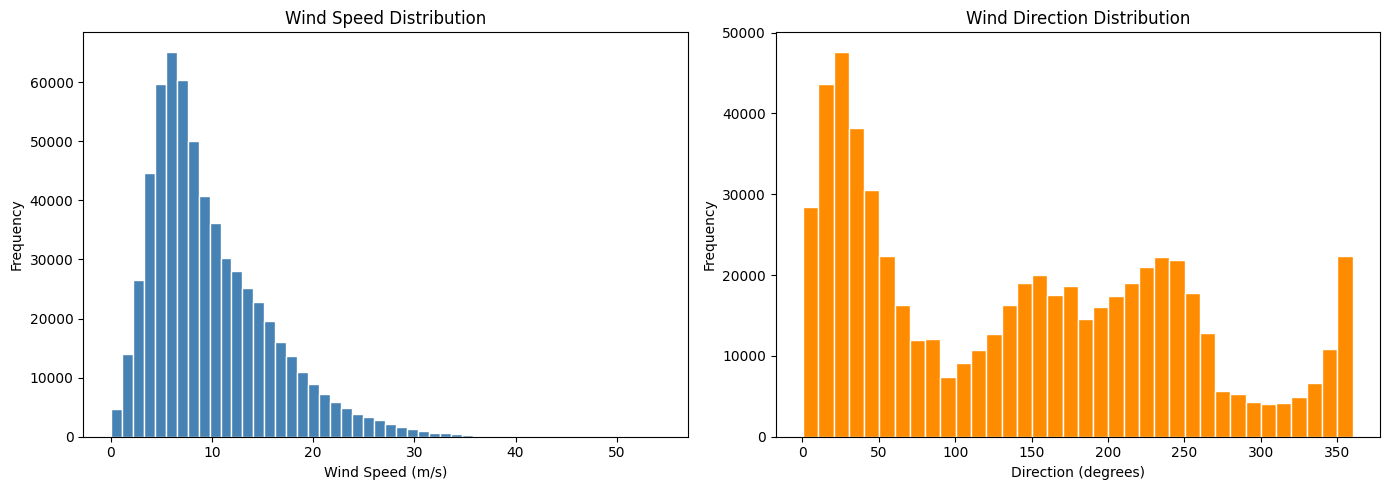

In [ ]:
# 6a. Wind speed distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wind_df["wind_speed_10m"].dropna().plot(kind="hist", bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Wind Speed Distribution")
axes[0].set_xlabel("Wind Speed (m/s)")

wind_df["wind_direction_10m"].dropna().plot(kind="hist", bins=36, ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Wind Direction Distribution")
axes[1].set_xlabel("Direction (degrees)")

plt.tight_layout()
plt.show()


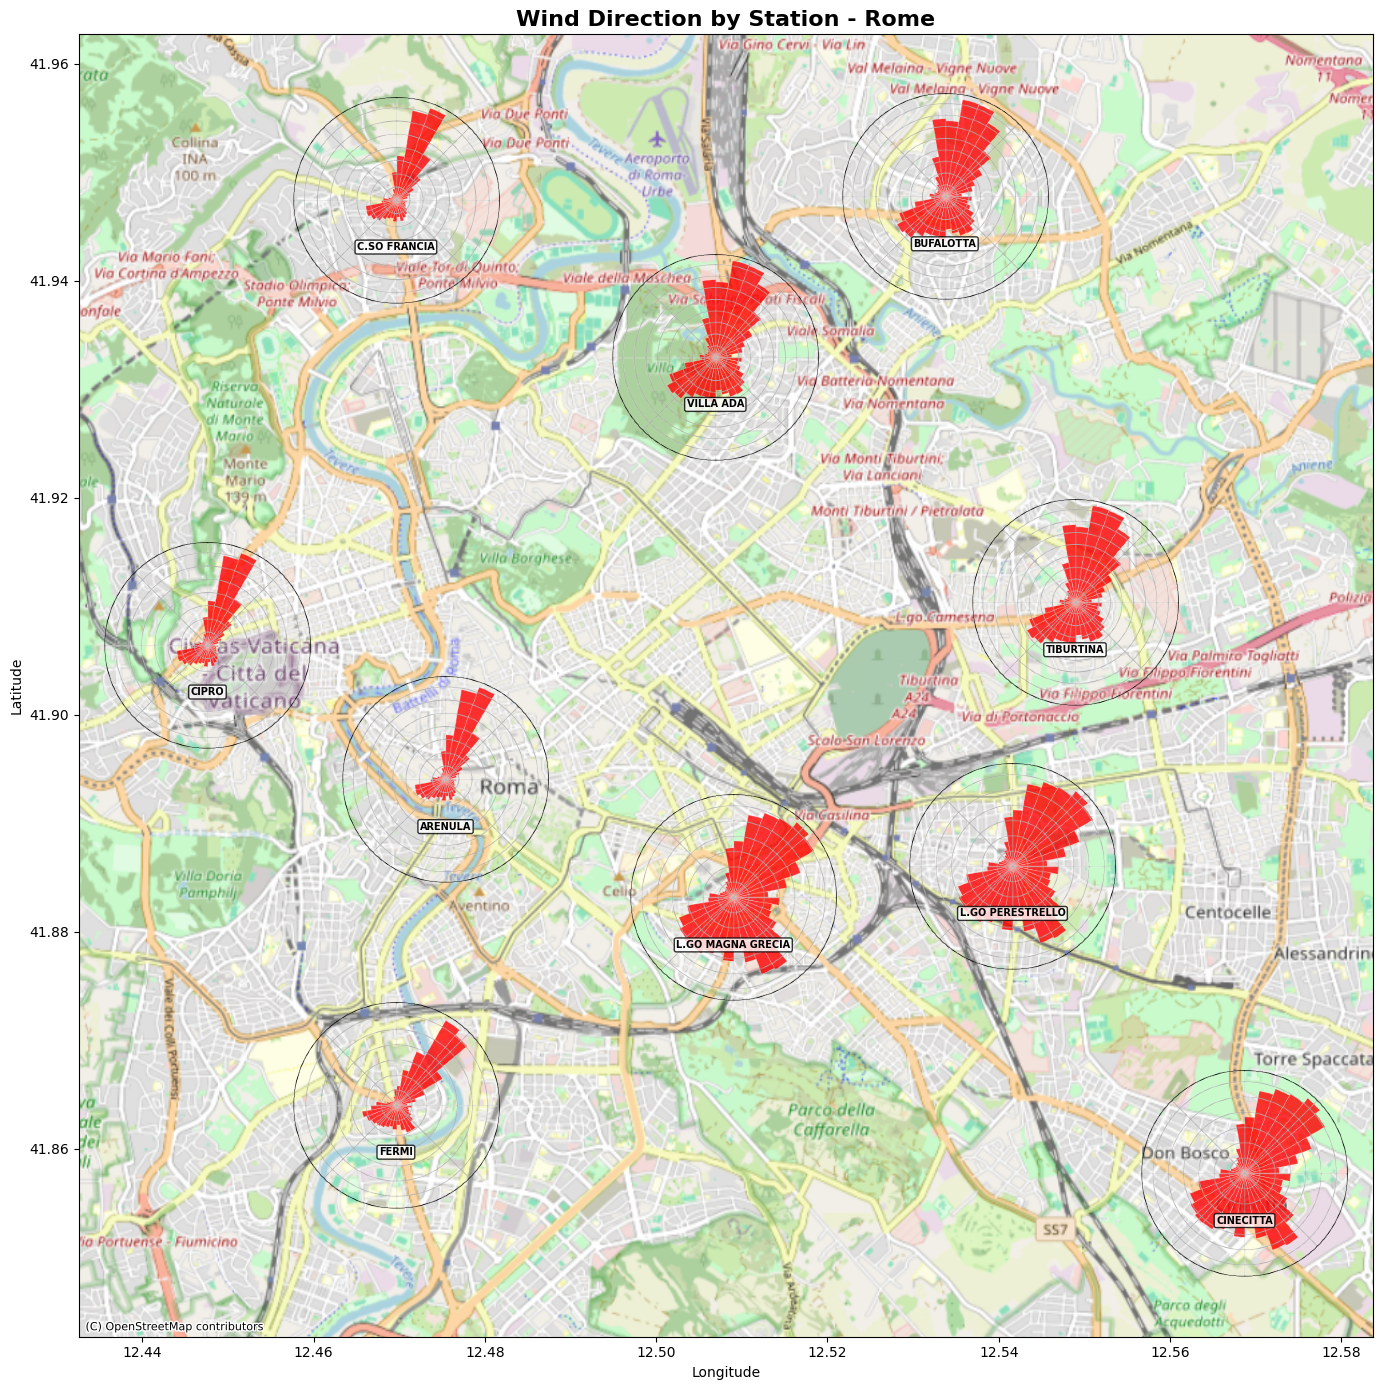

In [ ]:
import contextily as ctx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from io import BytesIO

stations_info = wind_df.groupby("station").agg({"latitude": "first", "longitude": "first"}).reset_index()
direction_bins = np.linspace(0, 360, 37)

fig, ax_map = plt.subplots(figsize=(14, 14))

# Set map bounds with padding
pad = 0.015
ax_map.set_xlim(stations_info["longitude"].min() - pad, stations_info["longitude"].max() + pad)
ax_map.set_ylim(stations_info["latitude"].min() - pad, stations_info["latitude"].max() + pad)

# Add basemap
ctx.add_basemap(ax_map, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

# For each station, create a mini wind rose and paste it on the map
for _, row in stations_info.iterrows():
    station = row["station"]
    lat, lon = row["latitude"], row["longitude"]

    # Create mini wind rose as an image
    fig_mini, ax_mini = plt.subplots(figsize=(4, 4), subplot_kw={"projection": "polar"})
    data = wind_df[wind_df["station"] == station]["wind_direction_10m"].dropna()
    counts, _ = np.histogram(data, bins=direction_bins)
    theta = np.deg2rad((direction_bins[:-1] + direction_bins[1:]) / 2)
    ax_mini.bar(theta, counts, width=np.deg2rad(10), color="red", alpha=0.8, edgecolor="white", linewidth=0.3)
    ax_mini.set_theta_zero_location("N")
    ax_mini.set_theta_direction(-1)
    ax_mini.set_yticklabels([])
    ax_mini.set_xticklabels([])
    ax_mini.patch.set_alpha(0)
    fig_mini.patch.set_alpha(0)

    # Save mini figure to buffer
    buf = BytesIO()
    fig_mini.savefig(buf, format="png", dpi=80, bbox_inches="tight", transparent=True)
    plt.close(fig_mini)
    buf.seek(0)

    # Read image and place on map
    from PIL import Image
    img = Image.open(buf)
    img_array = np.array(img)

    im = OffsetImage(img_array, zoom=0.6)
    ab = AnnotationBbox(im, (lon, lat), frameon=False)
    ax_map.add_artist(ab)

    # Add station name
    ax_map.annotate(station, (lon, lat), fontsize=7, fontweight="bold",
                    ha="center", va="top", xytext=(0, -30), textcoords="offset points",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

ax_map.set_title("Wind Direction by Station - Rome", fontsize=16, fontweight="bold")
ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

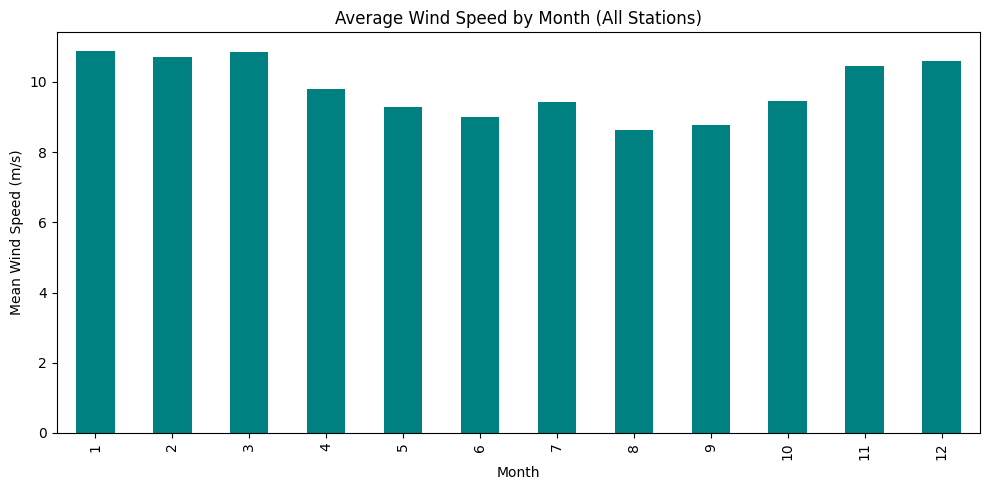

In [ ]:
# 6d. Monthly average wind speed
wind_df["month"] = wind_df["date"].dt.month
monthly = wind_df.groupby("month")["wind_speed_10m"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(kind="bar", ax=ax, color="teal")
ax.set_title("Average Wind Speed by Month (All Stations)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Wind Speed (m/s)")
plt.tight_layout()
plt.show()


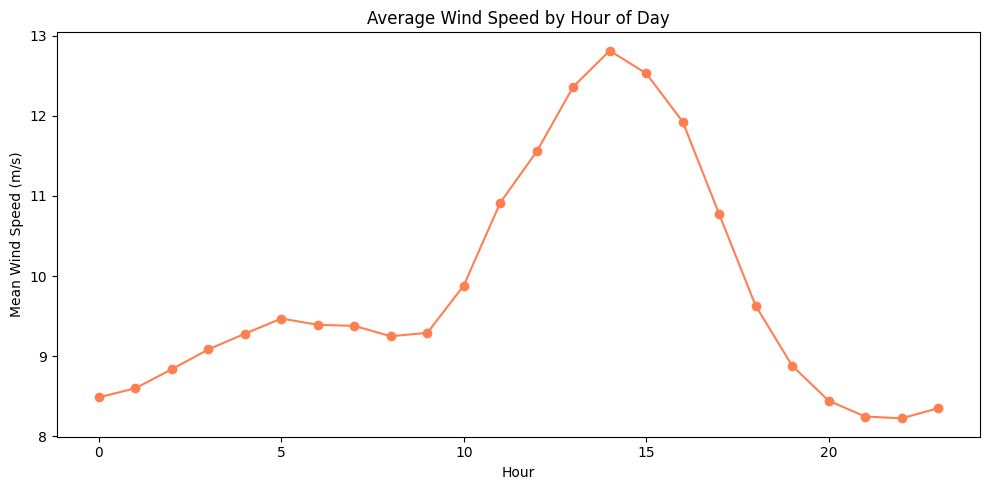

In [ ]:

# 6e. Hourly pattern
wind_df["hour"] = wind_df["date"].dt.hour
hourly = wind_df.groupby("hour")["wind_speed_10m"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
hourly.plot(kind="line", ax=ax, marker="o", color="coral")
ax.set_title("Average Wind Speed by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Mean Wind Speed (m/s)")
plt.tight_layout()
plt.show()


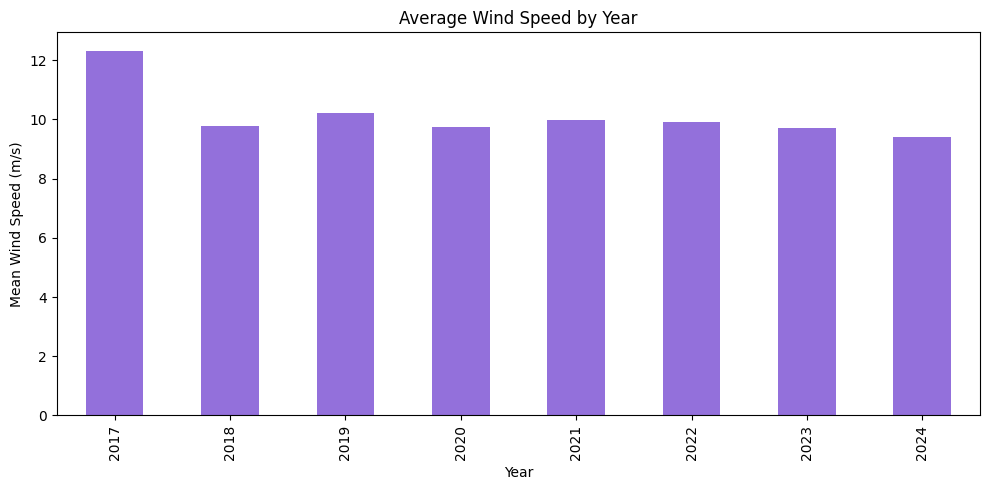

In [ ]:
# 6f. Yearly average wind speed
yearly = wind_df.groupby("Year")["wind_speed_10m"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
yearly.plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("Average Wind Speed by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Wind Speed (m/s)")
plt.tight_layout()
plt.show()


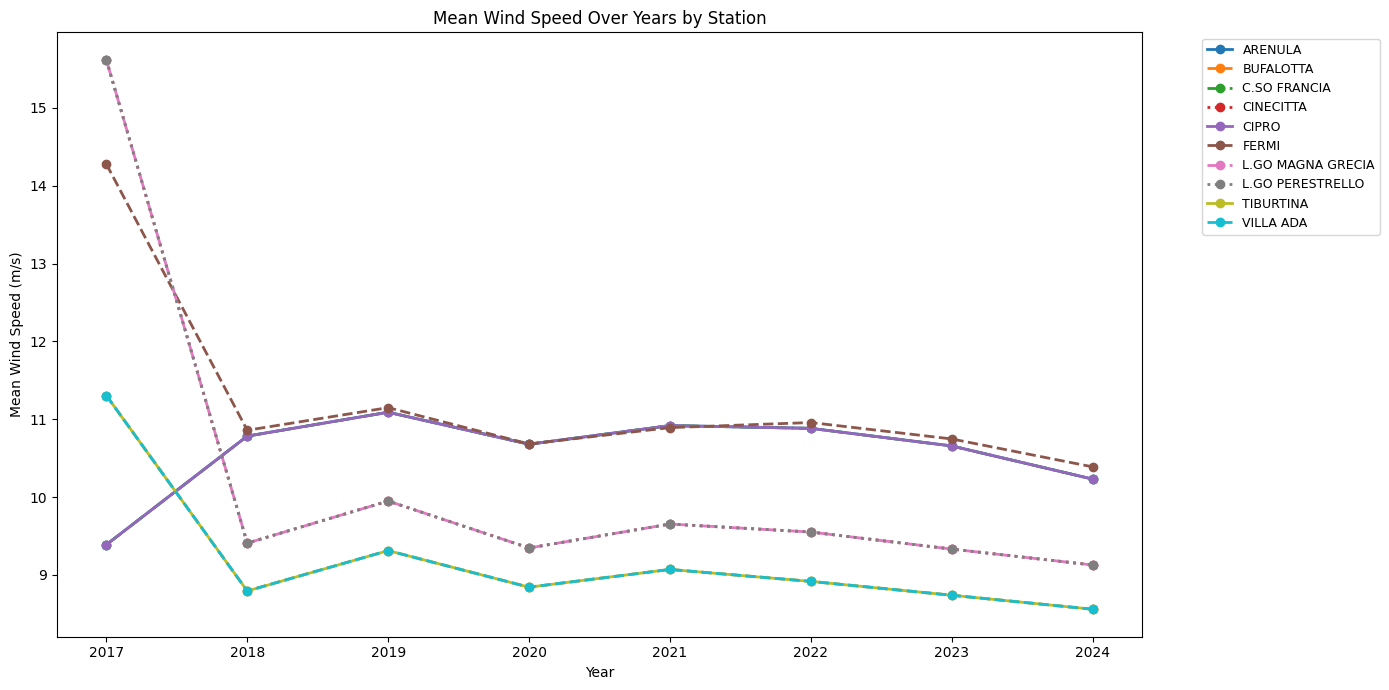

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
stations_sorted = sorted(wind_df["station"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(stations_sorted)))
linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-", "--"]

for i, station in enumerate(stations_sorted):
    sub = wind_df[wind_df["station"] == station].groupby("Year")["wind_speed_10m"].mean()
    ax.plot(sub.index, sub.values, marker="o", linewidth=2,
            label=station, color=colors[i], linestyle=linestyles[i])

ax.set_title("Mean Wind Speed Over Years by Station")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Wind Speed (m/s)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 7. ZERO & NEGATIVE VALUES
# ============================================================
print("\n" + "=" * 60)
print("7. ZERO & NEGATIVE VALUES")
print("=" * 60)
for col in ["wind_speed_10m", "wind_direction_10m"]:
    zeros = (wind_df[col] == 0).sum()
    negs = (wind_df[col] < 0).sum()
    nulls = wind_df[col].isna().sum()
    print(f"  {col}: zeros={zeros:,} ({zeros/len(wind_df)*100:.2f}%) | "
          f"negatives={negs:,} | nulls={nulls:,}")


7. ZERO & NEGATIVE VALUES
  wind_speed_10m: zeros=256 (0.04%) | negatives=0 | nulls=0
  wind_direction_10m: zeros=0 (0.00%) | negatives=0 | nulls=0


In [ ]:
# 8. DUPLICATES
# ============================================================
print("\n" + "=" * 60)
print("8. DUPLICATES")
print("=" * 60)
print(f"Exact duplicate rows: {wind_df.duplicated().sum()}")
print(f"Duplicates by station + date: {wind_df.duplicated(subset=['station', 'date']).sum()}")


8. DUPLICATES
Exact duplicate rows: 0
Duplicates by station + date: 0


In [ ]:
print("\n" + "=" * 60)
print("9. DATA QUALITY SUMMARY")
print("=" * 60)
print(f"  Total rows: {len(wind_df):,}")
print(f"  Columns: {wind_df.shape[1]}")
print(f"  Columns with nulls: {(wind_df.isna().sum() > 0).sum()}")
print(f"  Exact duplicates: {wind_df.duplicated().sum()}")
print(f"  Unique stations: {wind_df['station'].nunique()}")
print(f"  Date range: {wind_df['date'].min()} to {wind_df['date'].max()}")
print(f"  Wind speed range: {wind_df['wind_speed_10m'].min():.2f} to {wind_df['wind_speed_10m'].max():.2f} m/s")
print(f"  Wind direction range: {wind_df['wind_direction_10m'].min():.1f} to {wind_df['wind_direction_10m'].max():.1f} degrees")


9. DATA QUALITY SUMMARY
  Total rows: 613,680
  Columns: 9
  Columns with nulls: 0
  Exact duplicates: 0
  Unique stations: 10
  Date range: 2017-12-31 23:00:00+00:00 to 2024-12-31 22:00:00+00:00
  Wind speed range: 0.00 to 54.28 m/s
  Wind direction range: 0.4 to 360.0 degrees


In [ ]:
wind_df.head()

,date,wind_speed_10m,wind_direction_10m,station,latitude,longitude
0,2017-12-31 23:00:00+00:00,9.387651,147.528820,ARENULA,41.894,12.4754
1,2018-01-01 00:00:00+00:00,9.885262,146.888640,ARENULA,41.894,12.4754
2,2018-01-01 01:00:00+00:00,9.793059,126.027466,ARENULA,41.894,12.4754
3,2018-01-01 02:00:00+00:00,10.636766,113.962494,ARENULA,41.894,12.4754
4,2018-01-01 03:00:00+00:00,11.384198,124.695220,ARENULA,41.894,12.4754


In [80]:
# Filter wind data to 2021-2024 to match air quality data range
wind_df["date"] = pd.to_datetime(wind_df["date"]).dt.tz_localize(None)
wind_df = wind_df[wind_df["date"].dt.year.between(2021, 2024)].copy()

print(f"Wind rows after filtering: {len(wind_df):,}")
print(f"Date range: {wind_df['date'].min()} to {wind_df['date'].max()}")

Wind rows after filtering: 350,630
Date range: 2021-01-01 00:00:00 to 2024-12-31 22:00:00


In [85]:
df_merged = pd.read_csv("df_merged.csv")

In [86]:
df_merged.head()

,Samplingpoint,Start,End,Value,Unit,Validity,Verification,Year,Air Quality Network,Air Quality Station Name,Pollutant,Air Pollutant Description,Longitude,Latitude,Altitude,Date
0,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 00:00:00,2021-01-01 01:00:00,2.34430,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01
1,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 01:00:00,2021-01-01 02:00:00,NaN,ug.m-3,-1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01
2,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 02:00:00,2021-01-01 03:00:00,2.32277,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01
3,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 03:00:00,2021-01-01 04:00:00,2.04669,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01
4,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 04:00:00,2021-01-01 05:00:00,1.75685,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01


In [88]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Get unique stations from both datasets
aq_stations = df_merged[["Air Quality Station Name", "Latitude", "Longitude"]].drop_duplicates()
wind_stations = wind_df[["station", "latitude", "longitude"]].drop_duplicates()

print("Matching air quality stations to closest wind stations:\n")

for _, aq in aq_stations.iterrows():
    min_dist = float("inf")
    closest = None
    for _, ws in wind_stations.iterrows():
        d = haversine(aq["Latitude"], aq["Longitude"], ws["latitude"], ws["longitude"])
        if d < min_dist:
            min_dist = d
            closest = ws["station"]
    print(f"  {aq['Air Quality Station Name']:20s} -> {closest:20s} ({min_dist:.2f} km)")

Matching air quality stations to closest wind stations:

  C.SO FRANCIA         -> C.SO FRANCIA         (0.00 km)


ValueError: Unknown format code 's' for object of type 'float'

In [89]:
wind_df.head()

,date,wind_speed_10m,wind_direction_10m,station,latitude,longitude
26305,2021-01-01 00:00:00,5.091168,44.999897,ARENULA,41.894,12.4754
26306,2021-01-01 01:00:00,7.244860,63.435013,ARENULA,41.894,12.4754
26307,2021-01-01 02:00:00,8.089994,122.275620,ARENULA,41.894,12.4754
26308,2021-01-01 03:00:00,7.200000,126.869990,ARENULA,41.894,12.4754
26309,2021-01-01 04:00:00,9.178235,115.559920,ARENULA,41.894,12.4754


In [90]:
df_merged.head()

,Samplingpoint,Start,End,Value,Unit,Validity,Verification,Year,Air Quality Network,Air Quality Station Name,Pollutant,Air Pollutant Description,Longitude,Latitude,Altitude,Date
0,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 00:00:00,2021-01-01 01:00:00,2.34430,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01
1,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 01:00:00,2021-01-01 02:00:00,NaN,ug.m-3,-1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01
2,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 02:00:00,2021-01-01 03:00:00,2.32277,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01
3,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 03:00:00,2021-01-01 04:00:00,2.04669,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01
4,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 04:00:00,2021-01-01 05:00:00,1.75685,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01


In [91]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Get unique wind stations
wind_stations = wind_df[["station", "latitude", "longitude"]].drop_duplicates()

# For each air quality station, find closest wind station
aq_stations = df_merged[["Air Quality Station Name", "Latitude", "Longitude"]].drop_duplicates()

station_mapping = {}
for _, aq in aq_stations.iterrows():
    min_dist = float("inf")
    closest = None
    for _, ws in wind_stations.iterrows():
        d = haversine(aq["Latitude"], aq["Longitude"], ws["latitude"], ws["longitude"])
        if d < min_dist:
            min_dist = d
            closest = ws["station"]
    station_mapping[aq["Air Quality Station Name"]] = closest

# Add closest wind station column to df_merged
df_merged["wind_station"] = df_merged["Air Quality Station Name"].map(station_mapping)

print("Station mapping:")
for aq, ws in station_mapping.items():
    print(f"  {aq} -> {ws}")

Station mapping:
  C.SO FRANCIA -> C.SO FRANCIA
  nan -> None


In [96]:
df_merged.head()

,Samplingpoint,Start,End,Value,Unit,Validity,Verification,Year,Air Quality Network,Air Quality Station Name,Pollutant,Air Pollutant Description,Longitude,Latitude,Altitude,Date,wind_station
0,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 00:00:00,2021-01-01 01:00:00,2.34430,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA
1,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 01:00:00,2021-01-01 02:00:00,NaN,ug.m-3,-1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA
2,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 02:00:00,2021-01-01 03:00:00,2.32277,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA
3,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 03:00:00,2021-01-01 04:00:00,2.04669,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA
4,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 04:00:00,2021-01-01 05:00:00,1.75685,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA


In [97]:
wind_df.head()

,date,wind_speed_10m,wind_direction_10m,station,latitude,longitude
26305,2021-01-01 00:00:00,5.091168,44.999897,ARENULA,41.894,12.4754
26306,2021-01-01 01:00:00,7.244860,63.435013,ARENULA,41.894,12.4754
26307,2021-01-01 02:00:00,8.089994,122.275620,ARENULA,41.894,12.4754
26308,2021-01-01 03:00:00,7.200000,126.869990,ARENULA,41.894,12.4754
26309,2021-01-01 04:00:00,9.178235,115.559920,ARENULA,41.894,12.4754


In [99]:
df_merged["Start"] = pd.to_datetime(df_merged["Start"], format="mixed")
wind_df["date"] = pd.to_datetime(wind_df["date"], format="mixed")

In [100]:
# Make sure both datetimes are aligned
df_merged["Start"] = pd.to_datetime(df_merged["Start"])
wind_df["date"] = pd.to_datetime(wind_df["date"])

# Round both to nearest hour to ensure matching
df_merged["hour_key"] = df_merged["Start"].dt.floor("H")
wind_df["hour_key"] = wind_df["date"].dt.floor("H")

# Merge: match wind station + hour
df_wind_merged = pd.merge(
    df_merged,
    wind_df[["station", "hour_key", "wind_speed_10m", "wind_direction_10m"]],
    left_on=["wind_station", "hour_key"],
    right_on=["station", "hour_key"],
    how="left"
)

# Drop extra columns
df_wind_merged = df_wind_merged.drop(columns=["station", "hour_key"])

matched = df_wind_merged["wind_speed_10m"].notna().sum()
total = len(df_wind_merged)
print(f"Rows: {total:,}")
print(f"Wind data matched: {matched:,} ({matched/total*100:.1f}%)")

Rows: 69,272
Wind data matched: 69,270 (100.0%)


/tmp/ipykernel_335/1020535443.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_merged["hour_key"] = df_merged["Start"].dt.floor("H")
/tmp/ipykernel_335/1020535443.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  wind_df["hour_key"] = wind_df["date"].dt.floor("H")


In [102]:
df_wind_merged.head()

,Samplingpoint,Start,End,Value,Unit,Validity,Verification,Year,Air Quality Network,Air Quality Station Name,Pollutant,Air Pollutant Description,Longitude,Latitude,Altitude,Date,wind_station,wind_speed_10m,wind_direction_10m
0,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 00:00:00,2021-01-01 01:00:00,2.34430,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,5.091168,44.999897
1,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 01:00:00,2021-01-01 02:00:00,NaN,ug.m-3,-1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,7.244860,63.435013
2,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 02:00:00,2021-01-01 03:00:00,2.32277,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,8.089994,122.275620
3,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 03:00:00,2021-01-01 04:00:00,2.04669,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,7.200000,126.869990
4,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 04:00:00,2021-01-01 05:00:00,1.75685,ug.m-3,1.0,1.0,2021.0,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0,2021-01-01,C.SO FRANCIA,9.178235,115.559920


In [103]:
df_wind_merged = df_wind_merged.to_csv("air_wind_last_.csv")

In [104]:
dataset1 = pd.read_csv("air_wind_last_.csv")

In [106]:
dataset1.columns

Index(['Unnamed: 0', 'Samplingpoint', 'Start', 'End', 'Value', 'Unit',
       'Validity', 'Verification', 'Year', 'Air Quality Network',
       'Air Quality Station Name', 'Pollutant', 'Air Pollutant Description',
       'Longitude', 'Latitude', 'Altitude', 'Date', 'wind_station',
       'wind_speed_10m', 'wind_direction_10m'],
      dtype='object')

In [110]:
non_numeric = dataset1.select_dtypes(include="object").columns
for col in non_numeric:
    print(f"  {col}: {dataset1[col].nunique()} unique")

  Samplingpoint: 2 unique
  Start: 35064 unique
  End: 35064 unique
  Unit: 1 unique
  Air Quality Network: 1 unique
  Air Quality Station Name: 1 unique
  Pollutant: 2 unique
  Air Pollutant Description: 2 unique
  Date: 1461 unique
  wind_station: 1 unique


#Cars Dataset

In [ ]:
df_cars = pd.read_csv("car-data_big.csv")

/tmp/ipykernel_834/3397300776.py:1: DtypeWarning: Columns (6,35,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cars = pd.read_csv("car-data_big.csv")


In [ ]:
df_cars.columns

NameError: name 'df_cars' is not defined

In [ ]:
import pandas as pd

# Load only the columns you need — drastically reduces memory
df_cars = pd.read_csv("car-data_big.csv", usecols=[
    "ID",
    "year",
    "Ft",
    "ep (KW)",
    "Date of registration"


])


/tmp/ipykernel_15904/2499772968.py:4: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cars = pd.read_csv("car-data_big.csv", usecols=[


In [ ]:
df_cars

,ID,Ft,ep (KW),year,Date of registration
0,281483,petrol,85.0,2019,NaN
1,281484,diesel,120.0,2019,NaN
2,281485,petrol,70.0,2019,NaN
3,281486,petrol,51.0,2019,NaN
4,281487,petrol,70.0,2019,NaN
...,...,...,...,...,...
9186900,160926061,electric,70.0,2024,2024-09-02
9186901,160926062,diesel,75.0,2024,2024-02-27
9186902,160926063,lpg,74.0,2024,2024-01-25
9186903,160926064,diesel,210.0,2024,2024-05-21


In [ ]:
# ============================================================
# 1. BASIC STRUCTURE
# ============================================================
print("=" * 60)
print("1. BASIC STRUCTURE")
print("=" * 60)
print(f"Shape: {df_cars.shape[0]:,} rows x {df_cars.shape[1]} columns")
print(f"\nColumns: {df_cars.columns.tolist()}")
print(f"\nData types:")
print(df_cars.dtypes)
print(f"\nFirst 5 rows:")
print(df_cars.head())


1. BASIC STRUCTURE
Shape: 9,186,905 rows x 5 columns

Columns: ['ID', 'Ft', 'ep (KW)', 'year', 'Date of registration']

Data types:
ID                        int64
Ft                       object
ep (KW)                 float64
year                      int64
Date of registration     object
dtype: object

First 5 rows:
       ID      Ft  ep (KW)  year Date of registration
0  281483  petrol     85.0  2019                  NaN
1  281484  diesel    120.0  2019                  NaN
2  281485  petrol     70.0  2019                  NaN
3  281486  petrol     51.0  2019                  NaN
4  281487  petrol     70.0  2019                  NaN


In [ ]:
# ============================================================
# 2. SUMMARY STATISTICS
# ============================================================
print("\n" + "=" * 60)
print("2. SUMMARY STATISTICS")
print("=" * 60)
print(df_cars.describe())



2. SUMMARY STATISTICS
                 ID       ep (KW)          year
count  9.186905e+06  9.183744e+06  9.186905e+06
mean   7.033781e+07  8.805217e+01  2.021424e+03
std    6.026699e+07  4.096723e+01  1.775777e+00
min    2.611500e+04  5.000000e+00  2.019000e+03
25%    4.192267e+06  6.300000e+01  2.020000e+03
50%    4.723938e+07  8.100000e+01  2.021000e+03
75%    1.293209e+08  1.000000e+02  2.023000e+03
max    1.609261e+08  9.320000e+02  2.024000e+03


In [ ]:
print("\n" + "=" * 60)
print("3. MISSING DATA")
print("=" * 60)
nulls = df_cars.isna().sum()
null_pct = (df_cars.isna().sum() / len(df_cars) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())



3. MISSING DATA
                        count  percent
Date of registration  3298240    35.90
ep (KW)                  3161     0.03
ID                          0     0.00
Ft                          0     0.00
year                        0     0.00


In [ ]:
# ============================================================
# 4. UNIQUE VALUES
# ============================================================
print("\n" + "=" * 60)
print("4. UNIQUE VALUES")
print("=" * 60)
for col in df_cars.columns:
    print(f"  {col}: {df_cars[col].nunique()} unique")



4. UNIQUE VALUES
  ID: 8979207 unique
  Ft: 19 unique
  ep (KW): 344 unique
  year: 6 unique
  Date of registration: 1037 unique


In [ ]:
# ============================================================
print("\n" + "=" * 60)
print("8. DUPLICATES")
print("=" * 60)
print(f"Exact duplicate rows: {df_cars.duplicated().sum()}")
print(f"Duplicate IDs: {df_cars.duplicated(subset=['ID']).sum()}")


8. DUPLICATES
Exact duplicate rows: 0
Duplicate IDs: 207698


In [ ]:
# 5. KEY DISTRIBUTIONS
# ============================================================
print("\n" + "=" * 60)
print("5. KEY DISTRIBUTIONS")
print("=" * 60)

print("\nFuel Types:")
print(df_cars["Ft"].value_counts())

print("\nRegistration Year:")
print(df_cars["year"].value_counts().sort_index())

# Standardize to lowercase first
df_cars["Ft"] = df_cars["Ft"].str.lower().str.strip()

print("After standardizing:")
print(df_cars["Ft"].value_counts())


5. KEY DISTRIBUTIONS

Fuel Types:
Ft
petrol             2872495
PETROL             2274939
diesel             1429019
DIESEL             1174837
lpg                 423587
LPG                 316521
PETROL/ELECTRIC     151125
ELECTRIC            148919
electric            142360
petrol/electric     121034
NG                   65341
ng                   33438
DIESEL/ELECTRIC       9853
NG-BIOMETHANE         8380
ng-biomethane         8254
diesel/electric       6331
e85                    429
HYDROGEN                23
hydrogen                20
Name: count, dtype: int64

Registration Year:
year
2019    1917399
2020    1380839
2021    1456472
2022    1312627
2023    1564184
2024    1555384
Name: count, dtype: int64
After standardizing:
Ft
petrol             5147434
diesel             2603856
lpg                 740108
electric            291279
petrol/electric     272159
ng                   98779
ng-biomethane        16634
diesel/electric      16184
e85                    429
hydrogen 

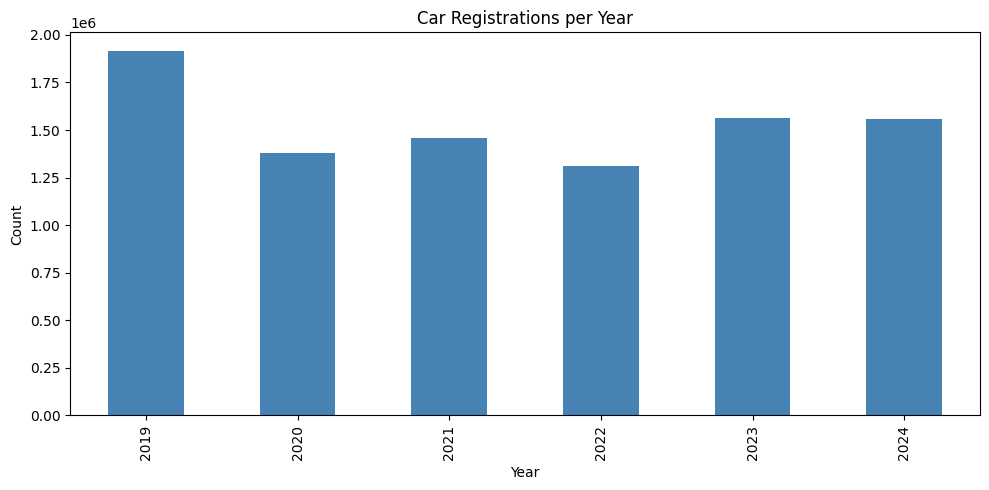

In [ ]:

# 6a. Registrations per year
fig, ax = plt.subplots(figsize=(10, 5))
df_cars["year"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Car Registrations per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


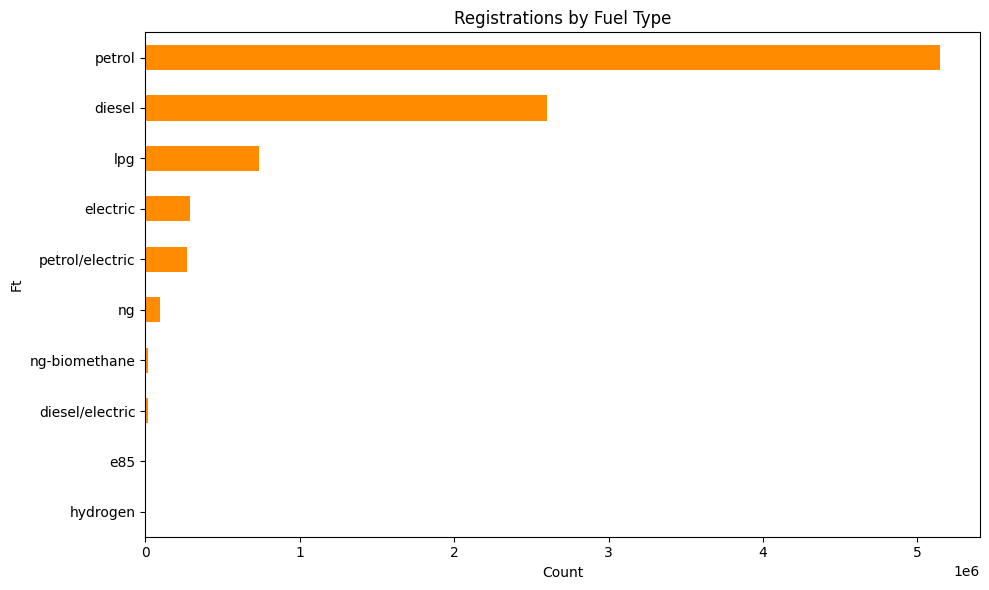

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
df_cars["Ft"].value_counts().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Registrations by Fuel Type")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()



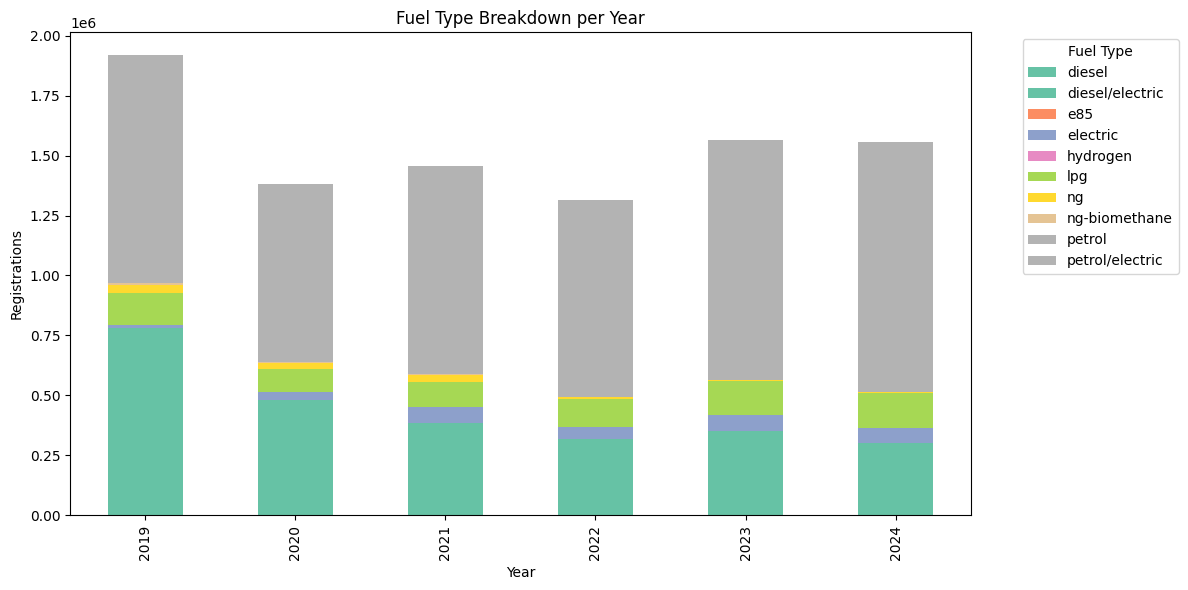

In [ ]:
fuel_year = df_cars.groupby(["year", "Ft"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 6))
fuel_year.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Fuel Type Breakdown per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Registrations")
ax.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


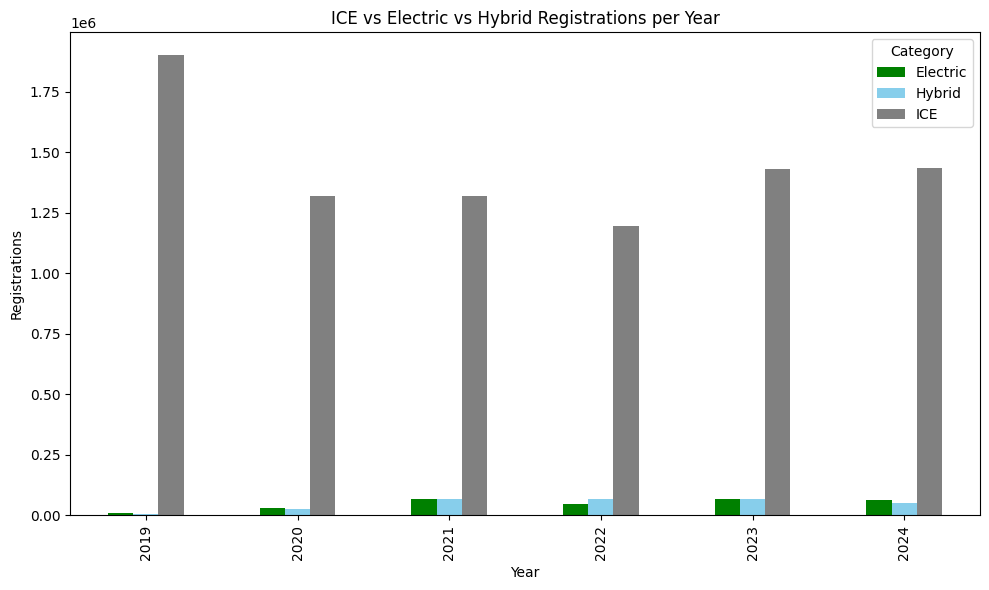

In [ ]:
def classify_fuel(ft):
    ft = str(ft).lower()
    if ft == "electric":
        return "Electric"
    elif ft in ["petrol/electric", "diesel/electric"]:
        return "Hybrid"
    else:
        return "ICE"

df_cars["fuel_category"] = df_cars["Ft"].apply(classify_fuel)

cat_year = df_cars.groupby(["year", "fuel_category"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 6))
cat_year.plot(kind="bar", ax=ax, color={"ICE": "gray", "Electric": "green", "Hybrid": "skyblue"})
ax.set_title("ICE vs Electric vs Hybrid Registrations per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Registrations")
ax.legend(title="Category")
plt.tight_layout()
plt.show()


In [ ]:
print("\n" + "=" * 60)
print("9. DATA QUALITY SUMMARY")
print("=" * 60)
print(f"  Total rows: {len(df_cars):,}")
print(f"  Columns: {df_cars.shape[1]}")
print(f"  Columns with nulls: {(df_cars.isna().sum() > 0).sum()}")
print(f"  Exact duplicates: {df_cars.duplicated().sum()}")
print(f"  Unique fuel types: {df_cars['Ft'].nunique()}")
print(f"  Year range: {df_cars['year'].min()} - {df_cars['year'].max()}")
print(f"  ICE: {(df_cars['fuel_category'] == 'ICE').sum():,}")
print(f"  Electric: {(df_cars['fuel_category'] == 'Electric').sum():,}")
print(f"  Hybrid: {(df_cars['fuel_category'] == 'Hybrid').sum():,}")


9. DATA QUALITY SUMMARY
  Total rows: 9,186,905
  Columns: 5
  Columns with nulls: 1
  Exact duplicates: 0
  Unique fuel types: 10
  Year range: 2019 - 2024
  ICE: 8,607,283
  Electric: 291,279
  Hybrid: 288,343


In [ ]:
print("Missing 'Date of registration' by year:")
print(df_cars.groupby("year")["Date of registration"].apply(lambda x: x.isna().sum()))

print("\nMissing % by year:")
print(df_cars.groupby("year")["Date of registration"].apply(lambda x: (x.isna().sum() / len(x) * 100).round(2)))

Missing 'Date of registration' by year:
year
2019    1917399
2020    1380839
2021          2
2022          0
2023          0
2024          0
Name: Date of registration, dtype: int64

Missing % by year:
year
2019    100.0
2020    100.0
2021      0.0
2022      0.0
2023      0.0
2024      0.0
Name: Date of registration, dtype: float64


In [ ]:
# Drop 'ep (KW)' — engine power not directly relevant to air quality analysis
# Fuel type and car count trends are more meaningful for emission impact
df_cars = df_cars.drop(columns=["ep (KW)"])

print(f"Remaining columns: {df_cars.columns.tolist()}")

Remaining columns: ['ID', 'Ft', 'year', 'Date of registration']


In [ ]:
# Drop 'ID' — identifier column, not needed for analysis
df_cars = df_cars.drop(columns=["ID"])

print(f"Remaining columns: {df_cars.columns.tolist()}")

Remaining columns: ['Ft', 'year', 'Date of registration']


In [ ]:
df_cars["fuel_category"].unique()

array(['Benzine', 'Diesel', 'Electric', 'Others', 'Hybrid'], dtype=object)

In [ ]:
# Group fuel types into 5 categories for cleaner analysis
# First standardize to lowercase
df_cars["Ft"] = df_cars["Ft"].str.lower().str.strip()

def classify_fuel(ft):
    ft = str(ft)
    if ft in ["petrol"]:
        return "Benzine"
    elif ft in ["diesel"]:
        return "Diesel"
    elif ft in ["petrol/electric", "diesel/electric"]:
        return "Hybrid"
    elif ft in ["electric"]:
        return "Electric"
    else:
        # lpg, ng, ng-biomethane, hydrogen, e85, etc.
        return "Others"

df_cars["fuel_category"] = df_cars["Ft"].apply(classify_fuel)

print("Fuel category breakdown:")
print(df_cars["fuel_category"].value_counts())
print(f"\n'Others' includes:")
others = df_cars[df_cars["fuel_category"] == "Others"]["Ft"].value_counts()
print(others)

Fuel category breakdown:
fuel_category
Benzine     5147434
Diesel      2603856
Others       855993
Electric     291279
Hybrid       288343
Name: count, dtype: int64

'Others' includes:
Ft
lpg              740108
ng                98779
ng-biomethane     16634
e85                 429
hydrogen             43
Name: count, dtype: int64


In [ ]:
df_cars.drop(columns = "Ft")

,year,Date of registration,fuel_category
0,2019,NaN,Benzine
1,2019,NaN,Diesel
2,2019,NaN,Benzine
3,2019,NaN,Benzine
4,2019,NaN,Benzine
...,...,...,...
9186900,2024,2024-09-02,Electric
9186901,2024,2024-02-27,Diesel
9186902,2024,2024-01-25,Others
9186903,2024,2024-05-21,Diesel


In [ ]:
# Remove years 2019 and 2020 — outside our analysis window (2021-2024)
before = len(df_cars)
df_cars = df_cars[df_cars["year"].between(2021, 2024)].copy()

print(f"Before: {before:,} rows")
print(f"After: {len(df_cars):,} rows")
print(f"Years: {sorted(df_cars['year'].unique())}")

Before: 9,186,905 rows
After: 5,888,667 rows
Years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
# Drop rows where 'Date of registration' is missing
before = len(df_cars)
df_cars = df_cars.dropna(subset=["Date of registration"])

print(f"Before: {before:,} rows")
print(f"After: {len(df_cars):,} rows")
print(f"Dropped: {before - len(df_cars):,} rows")

Before: 5,888,667 rows
After: 5,888,665 rows
Dropped: 2 rows


In [ ]:
df_cars.to_csv("df_cars_cleaned_date.csv", index=False)

In [ ]:
df_merged.head()

,Samplingpoint,Start,End,Value,Unit,Validity,Verification,Year,Air Quality Network,Air Quality Station Name,Pollutant,Air Pollutant Description,Longitude,Latitude,Altitude
0,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 00:00:00,2021-01-01 01:00:00,2.34430,ug.m-3,1,1,2021,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0
1,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 01:00:00,2021-01-01 02:00:00,NaN,ug.m-3,-1,1,2021,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0
2,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 02:00:00,2021-01-01 03:00:00,2.32277,ug.m-3,1,1,2021,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0
3,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 03:00:00,2021-01-01 04:00:00,2.04669,ug.m-3,1,1,2021,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0
4,SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,2021-01-01 04:00:00,2021-01-01 05:00:00,1.75685,ug.m-3,1,1,2021,NET.IT112A,C.SO FRANCIA,C6H6,Benzene (air),12.4696,41.9474,35.0


In [ ]:
# Daily average of each pollutant across all stations
# Each station measures specific pollutants — we take the mean of all stations measuring that pollutant per day

df_merged["Start"] = pd.to_datetime(df_merged["Start"])
df_merged["Date"] = df_merged["Start"].dt.date

daily_pollution = df_merged.groupby(["Date", "Pollutant"])["Value"].mean().reset_index()
daily_pollution.columns = ["Date", "Pollutant", "Daily_Mean_Value"]
daily_pollution["Date"] = pd.to_datetime(daily_pollution["Date"])

print(f"Shape: {daily_pollution.shape}")
print(f"Date range: {daily_pollution['Date'].min()} to {daily_pollution['Date'].max()}")
print(f"\nPollutants:")
print(daily_pollution["Pollutant"].value_counts())
print(f"\nSample:")
daily_pollution.head(10)

Shape: (16071, 3)
Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00

Pollutants:
Pollutant
C6H5-C2H5         1461
C6H5-CH3          1461
C6H6              1461
CO                1461
NO                1461
NO2               1461
NOX as NO2        1461
O3                1461
SO2               1461
m,p-C6H4(CH3)2    1461
o-C6H4-(CH3)2     1461
Name: count, dtype: int64

Sample:


,Date,Pollutant,Daily_Mean_Value
0,2021-01-01,C6H5-C2H5,0.138330
1,2021-01-01,C6H5-CH3,0.618120
2,2021-01-01,C6H6,0.776176
3,2021-01-01,CO,0.477877
4,2021-01-01,NO,7.245054
5,2021-01-01,NO2,21.506556
6,2021-01-01,NOX as NO2,30.031268
7,2021-01-01,O3,36.524583
8,2021-01-01,SO2,1.664405
9,2021-01-01,"m,p-C6H4(CH3)2",0.431304


In [ ]:
# Create daily dataset: each row = one day, each pollutant = one column with daily mean value
df_merged["Start"] = pd.to_datetime(df_merged["Start"])
df_merged["Date"] = df_merged["Start"].dt.date

# Pivot: rows = Date, columns = Pollutant name, values = daily mean
daily_pollution = df_merged.groupby(["Date", "Pollutant"])["Value"].mean().reset_index()
daily_pollution = daily_pollution.pivot(index="Date", columns="Pollutant", values="Value").reset_index()
daily_pollution.columns.name = None

print(f"Shape: {daily_pollution.shape}")
daily_pollution.head()

Shape: (1461, 12)


,Date,C6H5-C2H5,C6H5-CH3,C6H6,CO,NO,NO2,NOX as NO2,O3,SO2,"m,p-C6H4(CH3)2",o-C6H4-(CH3)2
0,2021-01-01,0.138330,0.618120,0.776176,0.477877,7.245054,21.506556,30.031268,36.524583,1.664405,0.431304,0.140326
1,2021-01-02,0.282417,0.785778,0.565700,0.343035,9.069485,22.796224,31.942065,54.308934,NaN,0.706631,0.298313
2,2021-01-03,0.178403,0.509055,0.450118,0.352923,6.520143,23.687135,29.702084,41.920842,NaN,0.334104,0.186090
3,2021-01-04,0.477731,2.106506,0.970795,0.501048,21.816645,45.073931,73.114447,28.807264,NaN,1.586115,0.694697
4,2021-01-05,0.398373,1.388518,0.807650,0.460127,20.865971,41.989214,66.933897,33.395765,NaN,1.047824,0.536811


In [ ]:
# Create weekly average from daily pollution data
daily_pollution["Date"] = pd.to_datetime(daily_pollution["Date"])

weekly_pollution = daily_pollution.set_index("Date").resample("W").mean().reset_index()

print(f"Shape: {weekly_pollution.shape}")
weekly_pollution.head()

Shape: (210, 12)


,Date,C6H5-C2H5,C6H5-CH3,C6H6,CO,NO,NO2,NOX as NO2,O3,SO2,"m,p-C6H4(CH3)2",o-C6H4-(CH3)2
0,2021-01-03,0.199717,0.637651,0.597331,0.391278,7.611561,22.663305,30.558472,44.251453,1.664405,0.490680,0.208243
1,2021-01-10,0.420861,1.490267,0.848497,0.504599,22.976701,40.170569,71.510939,21.874897,1.478168,1.087037,0.581126
2,2021-01-17,0.546596,2.450235,1.263401,0.600879,40.413382,42.030480,101.280612,18.811428,1.861567,1.672257,0.837936
3,2021-01-24,0.396127,1.976635,0.959540,0.612247,35.190581,41.087022,90.529920,34.555766,2.243094,1.418752,0.563594
4,2021-01-31,0.315452,2.903247,1.165614,0.642990,40.231887,47.110116,103.661253,25.078016,2.062485,1.397992,0.832741


In [ ]:
# Create week-year label like 1-2021, 2-2021, etc.
weekly_pollution["Week"] = weekly_pollution["Date"].dt.isocalendar().week.astype(int)
weekly_pollution["Year"] = weekly_pollution["Date"].dt.year
weekly_pollution["Week_Label"] = weekly_pollution["Week"].astype(str) + "-" + weekly_pollution["Year"].astype(str)

# Move Week_Label to front, drop Date
weekly_pollution = weekly_pollution[["Week_Label"] + [c for c in weekly_pollution.columns if c not in ["Week_Label", "Date", "Week", "Year"]]]

print(f"Shape: {weekly_pollution.shape}")


KeyError: 'Date'

In [ ]:
weekly_pollution

,Week_Label,C6H5-C2H5,C6H5-CH3,C6H6,CO,NO,NO2,NOX as NO2,O3,SO2,"m,p-C6H4(CH3)2",o-C6H4-(CH3)2
0,53-2021,0.199717,0.637651,0.597331,0.391278,7.611561,22.663305,30.558472,44.251453,1.664405,0.490680,0.208243
1,1-2021,0.420861,1.490267,0.848497,0.504599,22.976701,40.170569,71.510939,21.874897,1.478168,1.087037,0.581126
2,2-2021,0.546596,2.450235,1.263401,0.600879,40.413382,42.030480,101.280612,18.811428,1.861567,1.672257,0.837936
3,3-2021,0.396127,1.976635,0.959540,0.612247,35.190581,41.087022,90.529920,34.555766,2.243094,1.418752,0.563594
4,4-2021,0.315452,2.903247,1.165614,0.642990,40.231887,47.110116,103.661253,25.078016,2.062485,1.397992,0.832741
...,...,...,...,...,...,...,...,...,...,...,...,...
205,49-2024,0.998938,5.802348,2.128213,0.902509,28.791174,32.237184,73.254777,22.034707,NaN,4.679762,1.541582
206,50-2024,1.277060,6.767297,2.090136,1.018917,36.508835,37.965606,90.412800,14.912089,2.298260,5.687695,1.804624
207,51-2024,1.517801,8.818263,2.351382,1.110348,53.594162,40.207051,119.135796,23.909457,2.295438,6.735381,2.185161
208,52-2024,0.949739,3.828114,1.353100,0.860020,28.354147,28.999167,68.285131,34.957921,NaN,3.821425,1.322759


In [ ]:
# Set Week_Label as the index
weekly_pollution = weekly_pollution.set_index("Week_Label")

weekly_pollution.head()

,C6H5-C2H5,C6H5-CH3,C6H6,CO,NO,NO2,NOX as NO2,O3,SO2,"m,p-C6H4(CH3)2",o-C6H4-(CH3)2
Week_Label,,,,,,,,,,,
53-2021,0.199717,0.637651,0.597331,0.391278,7.611561,22.663305,30.558472,44.251453,1.664405,0.490680,0.208243
1-2021,0.420861,1.490267,0.848497,0.504599,22.976701,40.170569,71.510939,21.874897,1.478168,1.087037,0.581126
2-2021,0.546596,2.450235,1.263401,0.600879,40.413382,42.030480,101.280612,18.811428,1.861567,1.672257,0.837936
3-2021,0.396127,1.976635,0.959540,0.612247,35.190581,41.087022,90.529920,34.555766,2.243094,1.418752,0.563594
4-2021,0.315452,2.903247,1.165614,0.642990,40.231887,47.110116,103.661253,25.078016,2.062485,1.397992,0.832741


In [ ]:
# Monthly average
daily_pollution["Date"] = pd.to_datetime(daily_pollution["Date"])

monthly_pollution = daily_pollution.set_index("Date").resample("M").mean()
monthly_pollution.index = monthly_pollution.index.strftime("%m-%Y")
monthly_pollution.index.name = "Month"

print("Monthly:")
print(f"Shape: {monthly_pollution.shape}")
monthly_pollution.head()



Monthly:
Shape: (48, 11)


/tmp/ipykernel_16496/4106359579.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_pollution = daily_pollution.set_index("Date").resample("M").mean()


,C6H5-C2H5,C6H5-CH3,C6H6,CO,NO,NO2,NOX as NO2,O3,SO2,"m,p-C6H4(CH3)2",o-C6H4-(CH3)2
Month,,,,,,,,,,,
01-2021,0.398465,2.053408,1.014560,0.570930,32.081372,40.670233,85.824338,26.935326,1.979072,1.306591,0.655887
02-2021,0.340719,2.733323,1.201029,0.656324,28.365365,44.245933,84.047511,30.535141,1.769920,1.164190,0.675064
03-2021,0.285124,2.137003,0.876798,0.537578,15.226175,35.385109,55.006422,44.921863,1.749712,0.955434,0.426961
04-2021,0.388574,1.967681,0.762543,0.553656,12.222594,29.905397,45.397833,54.156991,1.407703,0.879546,0.455947
05-2021,0.489327,2.609158,0.908606,0.405484,10.030244,24.207022,36.668803,56.765372,1.542950,1.522186,0.607054


In [ ]:
# Yearly average
yearly_pollution = daily_pollution.set_index("Date").resample("Y").mean()
yearly_pollution.index = yearly_pollution.index.year
yearly_pollution.index.name = "Year"

print("\nYearly:")
print(f"Shape: {yearly_pollution.shape}")
yearly_pollution.head()


Yearly:
Shape: (4, 11)


/tmp/ipykernel_16496/2315735791.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_pollution = daily_pollution.set_index("Date").resample("Y").mean()


,C6H5-C2H5,C6H5-CH3,C6H6,CO,NO,NO2,NOX as NO2,O3,SO2,"m,p-C6H4(CH3)2",o-C6H4-(CH3)2
Year,,,,,,,,,,,
2021,0.639768,3.518759,1.124097,0.531556,18.925831,33.024310,59.512402,42.799032,2.007082,2.103958,0.893194
2022,0.758463,4.776690,1.363796,0.571791,18.780164,33.231305,60.355725,45.971247,3.104746,2.849922,1.093333
2023,0.653337,3.884225,1.118360,0.673010,20.783733,31.736065,59.445835,43.662179,4.103394,3.019116,1.569673
2024,0.910123,4.218336,1.237966,0.928116,20.448750,30.920033,56.671996,43.182988,3.150131,3.363024,1.040145


In [ ]:
daily_pollution.to_csv("daily_pollution.csv", index=False)
weekly_pollution.to_csv("weekly_pollution.csv")
monthly_pollution.to_csv("monthly_pollution.csv")
yearly_pollution.to_csv("yearly_pollution.csv")
df_merged.to_csv("df_merged.csv", index=False)